# Customer Churn Prediction & Retention Analytics
**Major Project – Individual Assignment | Telecom / Subscription Services | Machine Learning – Classification**

**Workflow:** Data → Statistics → EDA → Preprocessing → Feature Engineering → Modeling → Evaluation → Insights → Recommendations

**Business problem.** Customers who leave (churn) take recurring revenue with them, and winning a replacement customer costs far more than keeping an existing one. The goal is to (1) predict who is likely to churn, (2) understand *why*, and (3) turn that into concrete retention actions.

**Dataset:** IBM Telco Customer Churn (Kaggle: `blastchar/telco-customer-churn`) – 7,043 customers, 21 columns. Target: `Churn`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve)
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 12, "axes.titleweight": "bold"})
Path("images").mkdir(exist_ok=True); Path("outputs").mkdir(exist_ok=True)

def savefig(name):
    plt.tight_layout(); plt.savefig(f"images/{name}.png", dpi=150, bbox_inches="tight"); plt.show()

## A. Data Understanding

In [2]:
DATA_PATH = "data/Telco-Customer-Churn.csv"
if not Path(DATA_PATH).exists():   # e.g. running in Google Colab without the repo: fetch a public copy of the same dataset
    Path("data").mkdir(exist_ok=True)
    DATA_PATH = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Business meaning of each variable
| Column | Type | Business meaning |
|---|---|---|
| customerID | ID | Unique customer identifier (no predictive value – dropped) |
| gender, SeniorCitizen, Partner, Dependents | Demographic | Who the customer is / household situation |
| tenure | Numeric | Months the customer has been with the company |
| PhoneService, MultipleLines | Service | Phone subscription details |
| InternetService | Service | DSL / Fiber optic / None |
| OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport | Add-on | Value-added protection / support services |
| StreamingTV, StreamingMovies | Add-on | Entertainment add-ons |
| Contract | Account | Month-to-month / One year / Two year commitment |
| PaperlessBilling, PaymentMethod | Billing | Billing channel and how the customer pays |
| MonthlyCharges | Numeric | Current monthly bill |
| TotalCharges | Numeric | Lifetime amount billed (stored as text in the raw file) |
| **Churn** | **Target** | Whether the customer left in the last month |

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Numerical vs categorical variables, missing values, duplicates, unique values
print("Missing values (NaN):\n", df.isna().sum()[df.isna().sum() > 0], "\n(none shown = no NaN)\n")
print("Duplicate rows:", df.duplicated().sum(), "| Duplicate customerIDs:", df.customerID.duplicated().sum())

# TotalCharges is 'object' even though it should be numeric -> look for blanks hiding as text
tc_blank = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]
print("\nRows where TotalCharges is blank/non-numeric:", len(tc_blank))
display(tc_blank[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

nunique = df.nunique().to_frame("unique_values")
nunique["dtype"] = df.dtypes
nunique["sample_values"] = [list(df[c].unique()[:4]) for c in df.columns]
nunique

Missing values (NaN):
 Series([], dtype: int64) 
(none shown = no NaN)

Duplicate rows: 0 | Duplicate customerIDs: 0

Rows where TotalCharges is blank/non-numeric: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


,unique_values,dtype,sample_values
customerID,7043,str,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW]"
gender,2,str,"[Female, Male]"
SeniorCitizen,2,int64,"[0, 1]"
Partner,2,str,"[Yes, No]"
Dependents,2,str,"[No, Yes]"
tenure,73,int64,"[1, 34, 2, 45]"
PhoneService,2,str,"[No, Yes]"
MultipleLines,3,str,"[No phone service, No, Yes]"
InternetService,3,str,"[DSL, Fiber optic, No]"
OnlineSecurity,3,str,"[No, Yes, No internet service]"


**Findings**
- 7,043 customers × 21 columns; **no duplicate rows or customer IDs**.
- `TotalCharges` is stored as text because **11 rows contain a blank string**. All 11 have `tenure = 0` – they are brand-new customers who haven't been billed yet, so the correct value is **0**, not a statistical guess.
- `SeniorCitizen` is coded 0/1 while every other binary column uses Yes/No – an inconsistency we'll fix.
- Several add-on columns contain **"No internet service"** / **"No phone service"**, which is logically identical to "No" for that add-on – we'll consolidate them.

## B. Statistical Analysis

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan))
df.loc[df["tenure"] == 0, "TotalCharges"] = 0.0     # new customers: nothing billed yet
assert df["TotalCharges"].isna().sum() == 0

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
desc = df[num_cols].describe().T
desc["median"]   = df[num_cols].median()
desc["mode"]     = [df[c].mode()[0] for c in num_cols]
desc["variance"] = df[num_cols].var()
desc["IQR"]      = desc["75%"] - desc["25%"]
desc["skew"]     = df[num_cols].skew()
desc["range"]    = desc["max"] - desc["min"]
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,median,mode,variance,IQR,skew,range
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00,29.00,1.00,603.17,46.00,0.24,72.0
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75,70.35,20.05,905.41,54.35,-0.22,100.5
TotalCharges,7043.0,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80,1394.55,0.00,5138357.17,3388.05,0.96,8684.8


In [6]:
# Same statistics split by churn status
df[num_cols + ["Churn"]].groupby("Churn").agg(["mean", "median", "std"]).round(2).T

Churn                       No      Yes
tenure         mean      37.57    17.98
               median    38.00    10.00
               std       24.11    19.53
MonthlyCharges mean      61.27    74.44
               median    64.43    79.65
               std       31.09    24.67
TotalCharges   mean    2549.91  1531.80
               median  1679.52   703.55
               std     2329.95  1890.82

In [7]:
# Outlier check with the 1.5*IQR rule
for c in num_cols:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c:15s} IQR fences = [{lo:9.2f}, {hi:9.2f}]  -> {n} outliers")

tenure          IQR fences = [   -60.00,    124.00]  -> 0 outliers
MonthlyCharges  IQR fences = [   -46.02,    171.38]  -> 0 outliers
TotalCharges    IQR fences = [ -4683.52,   8868.67]  -> 0 outliers


**Business interpretation of the statistics**
- **Tenure** is roughly U-shaped (many customers at ~1 month *and* many at ~72 months): the company has a large pool of brand-new customers plus a loyal long-term base. The mean tenure (~32 months) sits well below the maximum (72) – there is a lot of early-life volume.
- **MonthlyCharges** is spread widely (≈ $18 – $119) and is not unimodal – the low cluster is phone-only customers, the high cluster is fibre/bundle customers.
- **TotalCharges** is strongly right-skewed (mean > median): a minority of long-tenure, high-bill customers generate a disproportionate share of lifetime revenue – losing them is expensive.
- The **IQR outlier rule flags no outliers** in any numeric column; the extreme values are real customers (e.g. 72-month tenure, $118 bill), not data errors, so nothing is removed.
- **Churners differ clearly from non-churners**: they have much *shorter* tenure and *higher* monthly charges (see table above) – a pattern we explore next.

## C. Exploratory Data Analysis

### C1. Target distribution (class balance)

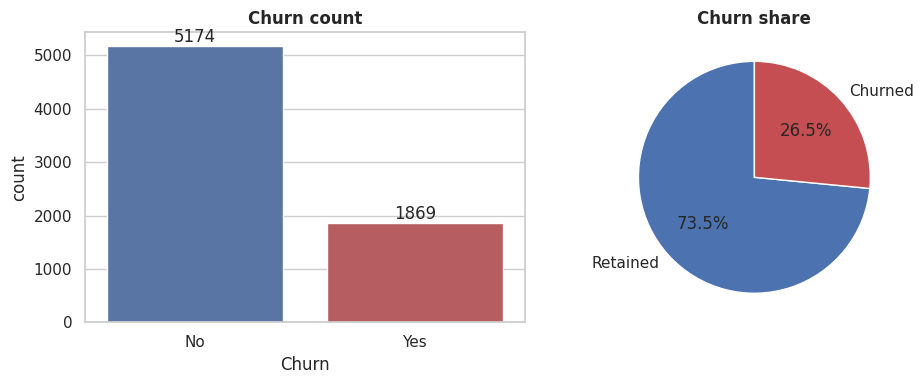

Churn rate: 26.5%  -> imbalanced (about 1 churner for every 2.8 retained)


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
counts = df["Churn"].value_counts()
sns.countplot(data=df, x="Churn", order=["No", "Yes"], ax=ax[0], palette=["#4c72b0", "#c44e52"])
for p in ax[0].patches: ax[0].annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
ax[0].set_title("Churn count")
ax[1].pie(counts[["No", "Yes"]], labels=["Retained", "Churned"], autopct="%1.1f%%", colors=["#4c72b0", "#c44e52"], startangle=90)
ax[1].set_title("Churn share")
savefig("01_churn_distribution")
print(f"Churn rate: {(df.Churn=='Yes').mean():.1%}  -> imbalanced (about 1 churner for every 2.8 retained)")

**Insight:** ~26.5% of customers churned. The classes are **imbalanced**, so plain accuracy is misleading (a model that predicts "no churn" for everyone scores ~73.5% while catching zero churners). This drives our metric choice and our use of class weights later.

### C2. Univariate analysis – numerical variables

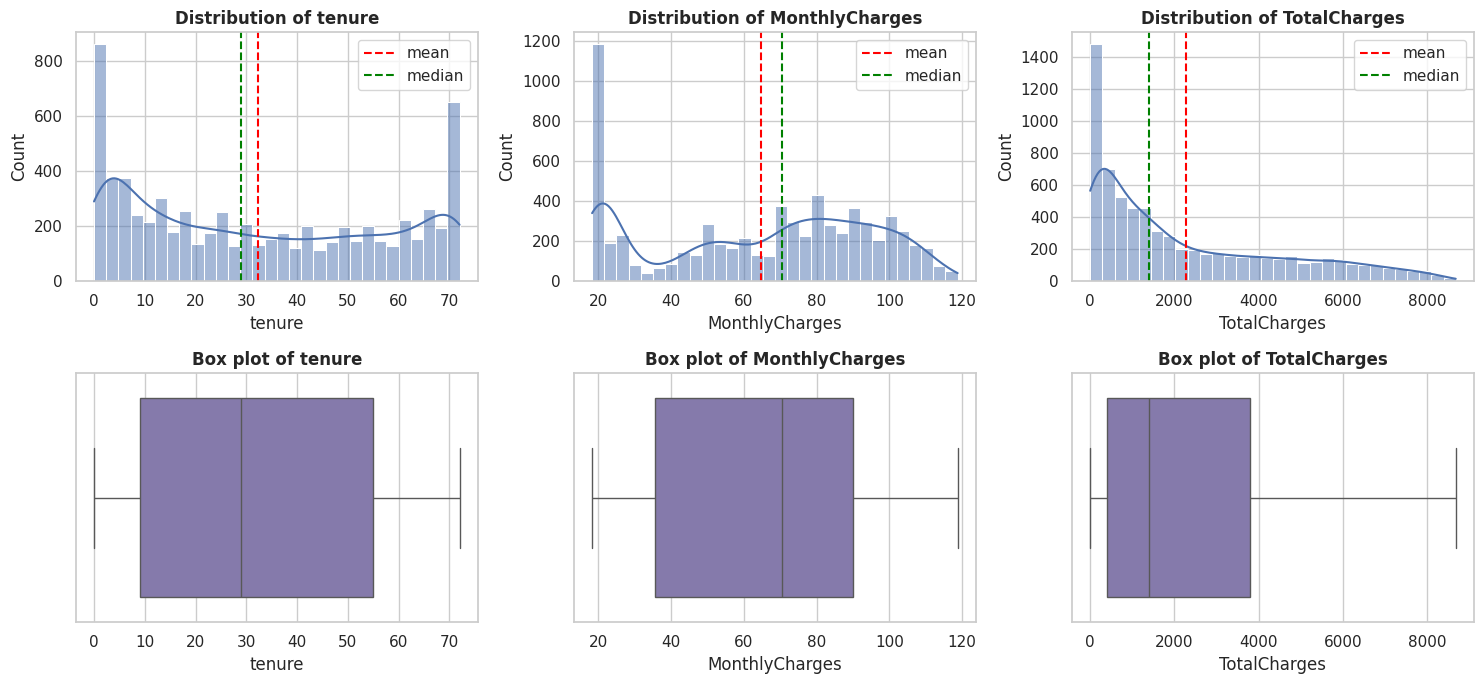

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for i, c in enumerate(num_cols):
    sns.histplot(df[c], kde=True, bins=30, ax=ax[0, i], color="#4c72b0")
    ax[0, i].axvline(df[c].mean(), color="red", ls="--", label="mean")
    ax[0, i].axvline(df[c].median(), color="green", ls="--", label="median"); ax[0, i].legend()
    ax[0, i].set_title(f"Distribution of {c}")
    sns.boxplot(x=df[c], ax=ax[1, i], color="#8172b3"); ax[1, i].set_title(f"Box plot of {c}")
savefig("02_numeric_univariate")

### C3. Univariate analysis – categorical variables

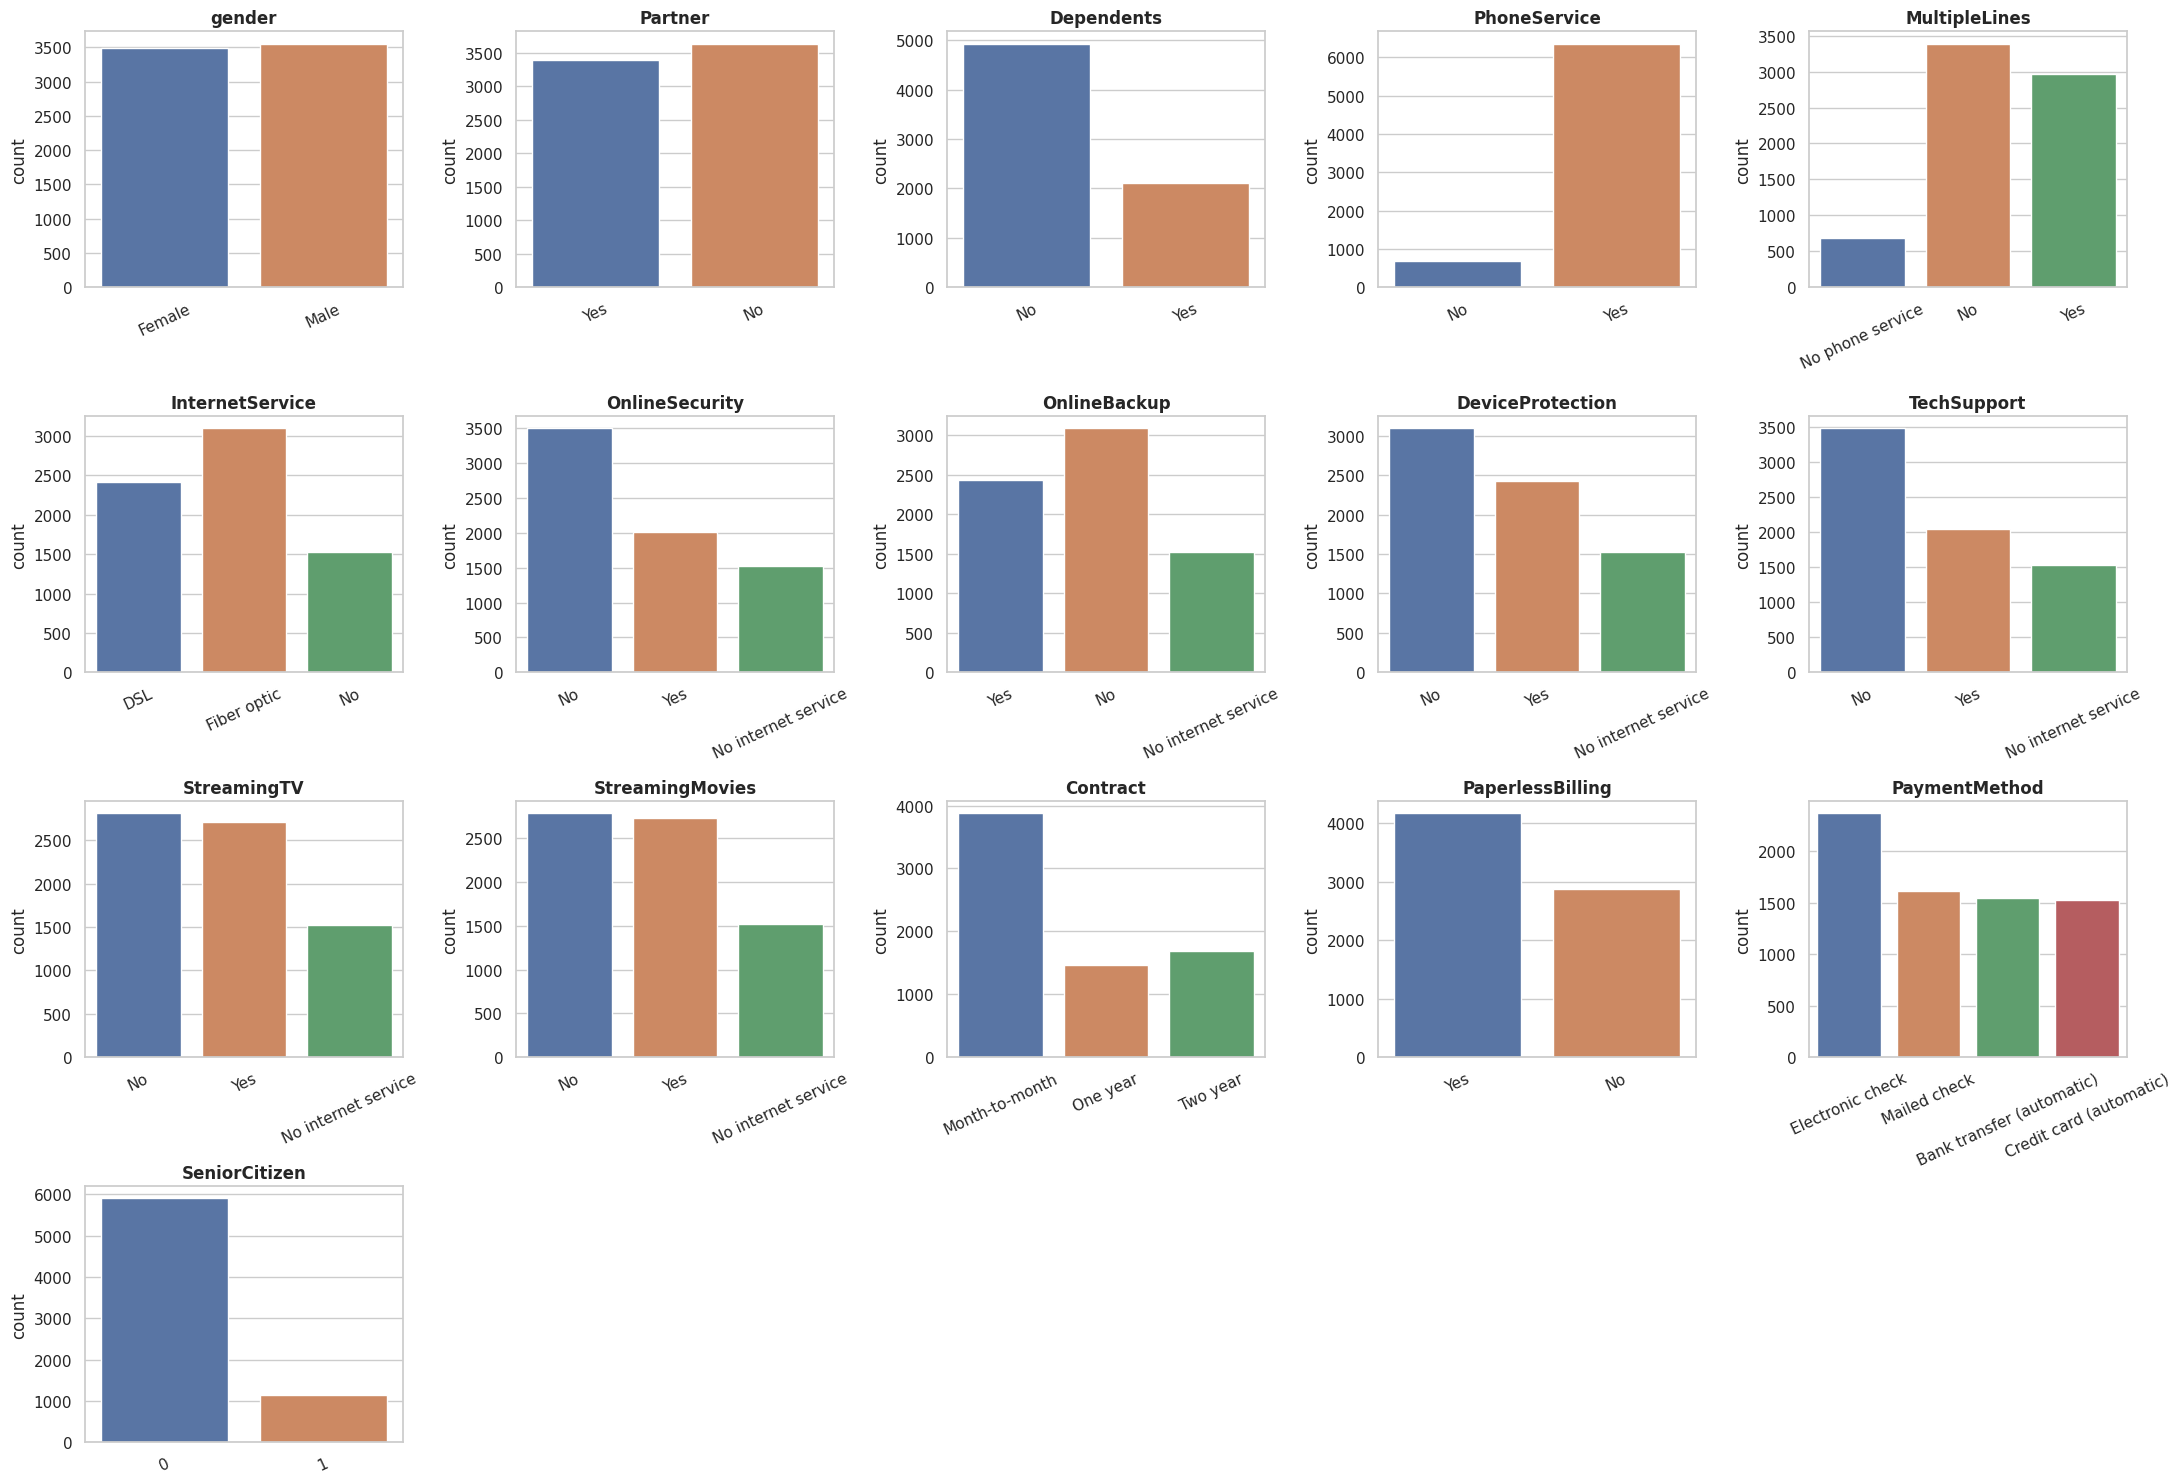

In [10]:
cat_cols = [c for c in df.select_dtypes(exclude="number").columns if c not in ["customerID", "Churn"]] + ["SeniorCitizen"]
fig, axes = plt.subplots(4, 5, figsize=(22, 15)); axes = axes.ravel()
for i, c in enumerate(cat_cols):
    sns.countplot(data=df, x=c, ax=axes[i], palette="deep"); axes[i].set_title(c)
    axes[i].tick_params(axis="x", rotation=25); axes[i].set_xlabel("")
for j in range(len(cat_cols), len(axes)): axes[j].axis("off")
savefig("03_categorical_univariate")

**Insights:** Month-to-month is the most common contract (~55%); fibre optic is the most common internet type (~44%); electronic check is the most common payment method. Gender is balanced, ~16% are senior citizens, and about 90% have phone service.

### C4. Bivariate analysis – numerical features vs churn

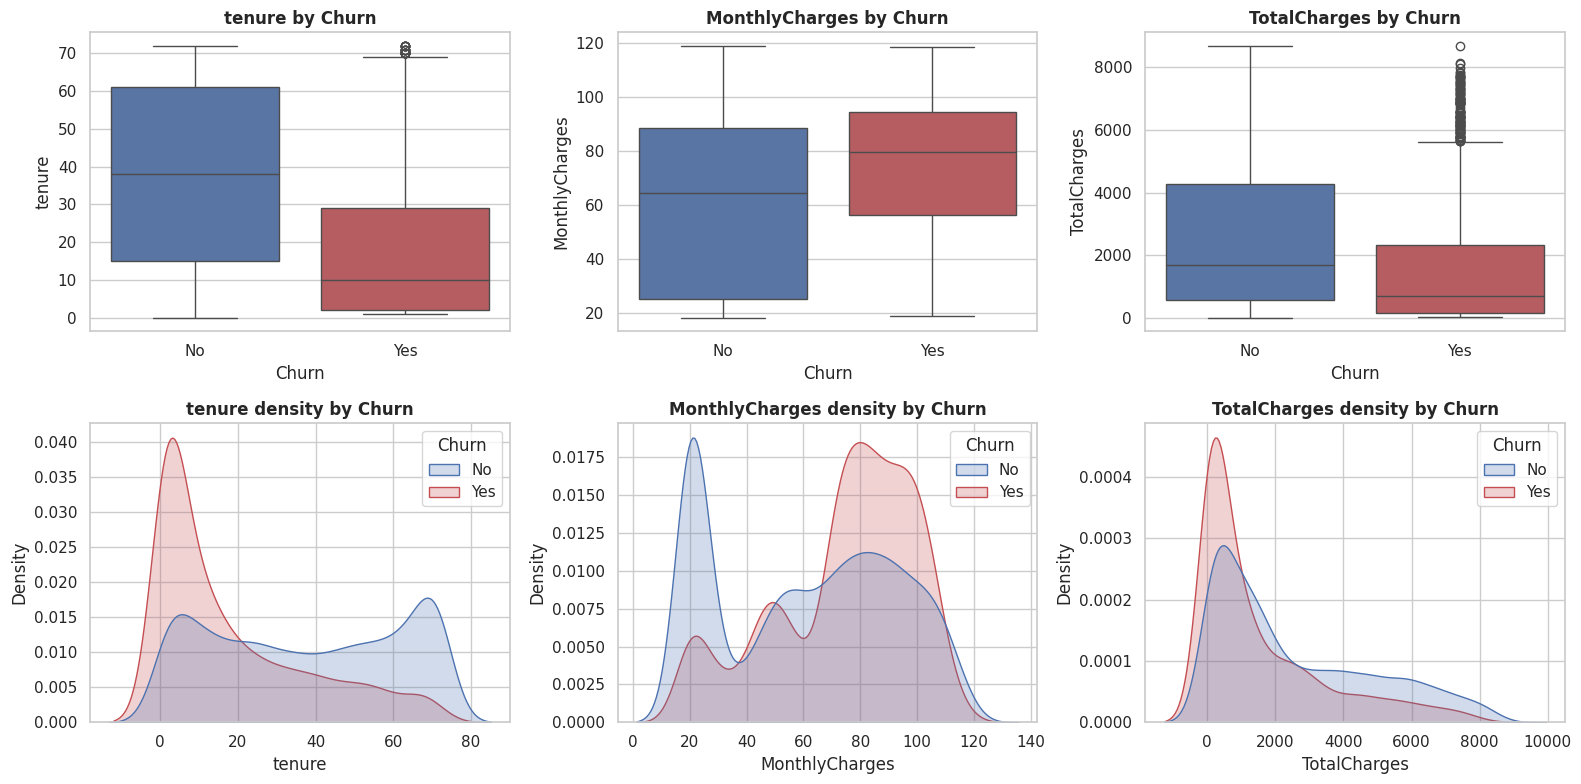

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for i, c in enumerate(num_cols):
    sns.boxplot(data=df, x="Churn", y=c, order=["No", "Yes"], ax=ax[0, i], palette=["#4c72b0", "#c44e52"]); ax[0, i].set_title(f"{c} by Churn")
    sns.kdeplot(data=df, x=c, hue="Churn", fill=True, common_norm=False, ax=ax[1, i], palette=["#4c72b0", "#c44e52"]); ax[1, i].set_title(f"{c} density by Churn")
savefig("04_numeric_vs_churn")

**Insights:** Churners cluster at **very low tenure** (median ~10 months vs ~38 for retained) and **higher monthly charges** (median ~$80 vs ~$65). Their `TotalCharges` is low simply because they leave early – tenure and TotalCharges move together.

### C5. Bivariate analysis – categorical features vs churn rate

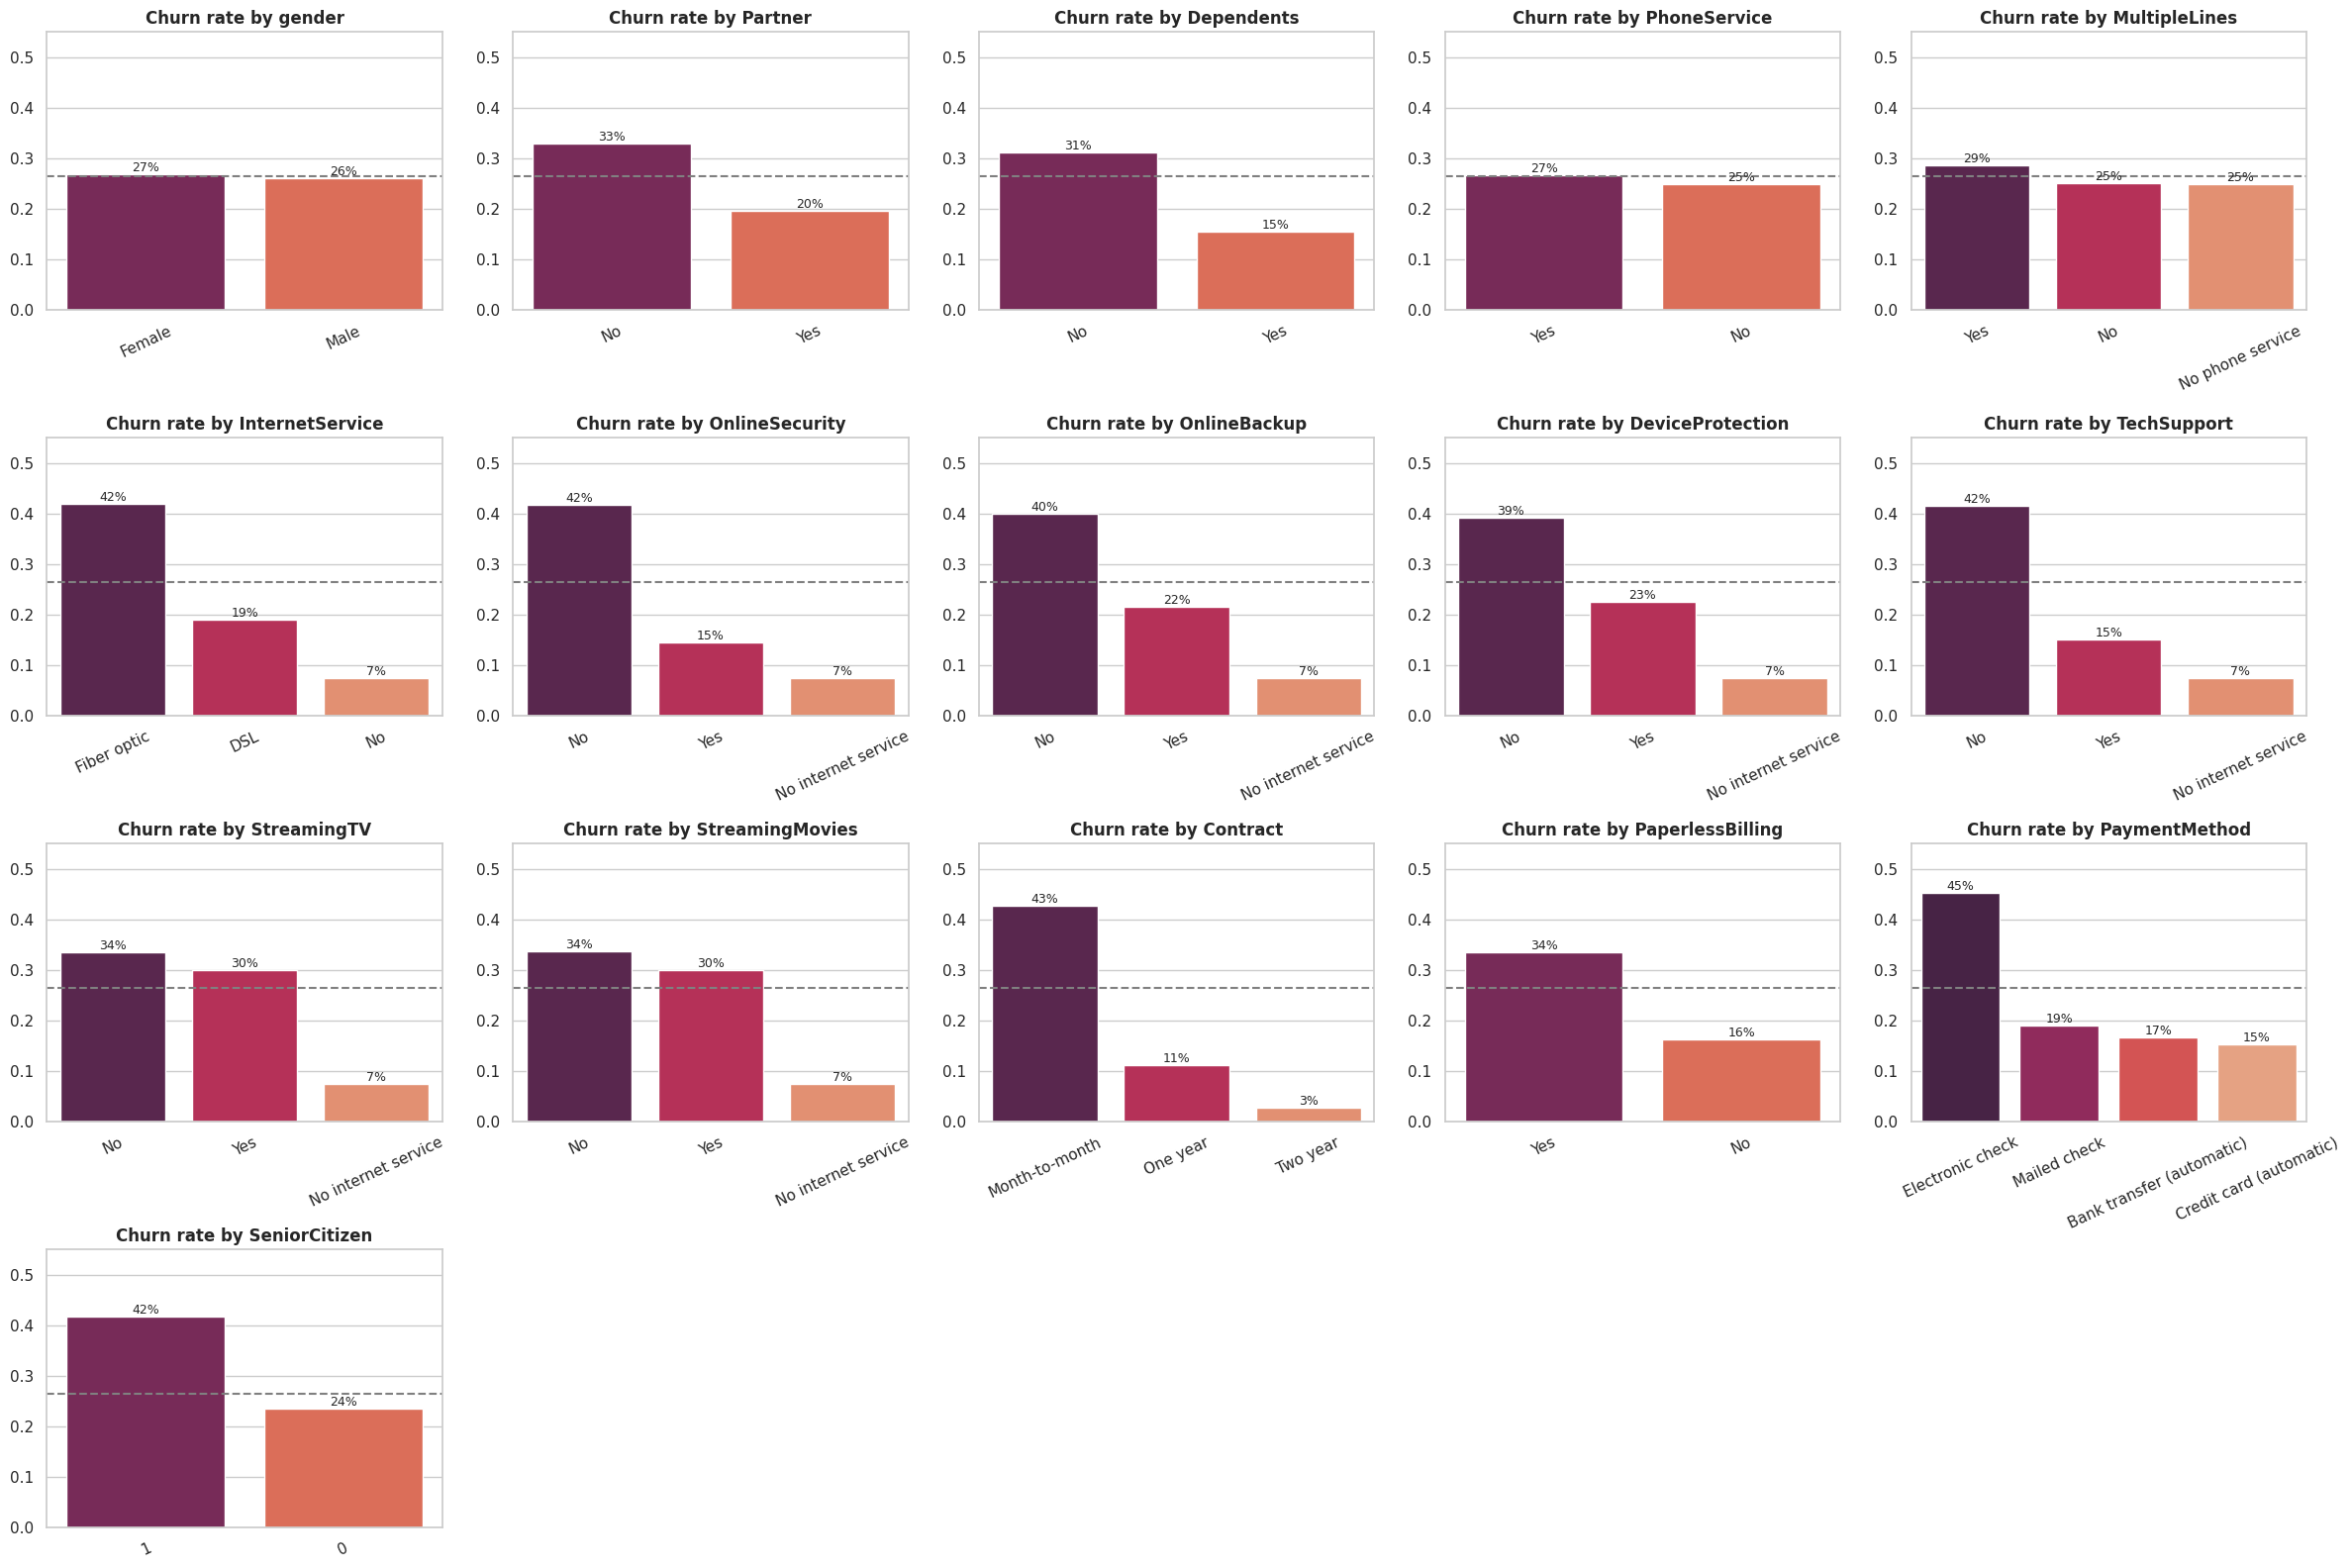

In [12]:
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
fig, axes = plt.subplots(4, 5, figsize=(24, 16)); axes = axes.ravel()
overall = df["ChurnFlag"].mean()
for i, c in enumerate(cat_cols):
    rate = df.groupby(c)["ChurnFlag"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], palette="rocket")
    axes[i].axhline(overall, color="grey", ls="--"); axes[i].set_title(f"Churn rate by {c}")
    axes[i].set_ylim(0, 0.55); axes[i].tick_params(axis="x", rotation=25); axes[i].set_xlabel("")
    for p in axes[i].patches: axes[i].annotate(f"{p.get_height():.0%}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=9)
for j in range(len(cat_cols), len(axes)): axes[j].axis("off")
savefig("05_categorical_vs_churn")

In [13]:
# Ranked table of the strongest single-variable segments (min 200 customers)
rows = []
for c in cat_cols:
    g = df.groupby(c)["ChurnFlag"].agg(["mean", "count"]).reset_index()
    for _, r in g.iterrows():
        rows.append((c, r[c], r["count"], r["mean"]))
seg = pd.DataFrame(rows, columns=["feature", "value", "customers", "churn_rate"]).query("customers >= 200")
seg["lift_vs_avg"] = seg["churn_rate"] / overall
print("Highest-churn segments"); display(seg.sort_values("churn_rate", ascending=False).head(8).round(3))
print("Lowest-churn segments");  display(seg.sort_values("churn_rate").head(8).round(3))

Highest-churn segments


,feature,value,customers,churn_rate,lift_vs_avg
39,PaymentMethod,Electronic check,2365.0,0.453,1.707
32,Contract,Month-to-month,3875.0,0.427,1.609
12,InternetService,Fiber optic,3096.0,0.419,1.579
14,OnlineSecurity,No,3498.0,0.418,1.574
42,SeniorCitizen,1.0,1142.0,0.417,1.571
23,TechSupport,No,3473.0,0.416,1.569
17,OnlineBackup,No,3088.0,0.399,1.505
20,DeviceProtection,No,3095.0,0.391,1.474


Lowest-churn segments


,feature,value,customers,churn_rate,lift_vs_avg
34,Contract,Two year,1695.0,0.028,0.107
13,InternetService,No,1526.0,0.074,0.279
21,DeviceProtection,No internet service,1526.0,0.074,0.279
15,OnlineSecurity,No internet service,1526.0,0.074,0.279
24,TechSupport,No internet service,1526.0,0.074,0.279
27,StreamingTV,No internet service,1526.0,0.074,0.279
18,OnlineBackup,No internet service,1526.0,0.074,0.279
30,StreamingMovies,No internet service,1526.0,0.074,0.279


**Key bivariate insights**
- **Contract is the single strongest signal:** month-to-month customers churn at ~43% vs ~11% (one-year) and ~3% (two-year).
- **Fibre-optic internet customers churn ~42%** vs ~19% for DSL and ~7% for no internet – despite paying the most.
- **No OnlineSecurity / TechSupport** → ~42% / ~42% churn vs ~15% / ~15% for customers who have them (customers with no internet at all churn only ~7%).
- **Electronic-check payers churn ~45%**, versus ~15–17% for automatic payment methods (bank transfer / credit card) and ~19% for mailed check.
- **Paperless billing customers churn ~34%** vs ~16% for paper billing.
- **Senior citizens (~42%)**, customers **without a partner (~33%)** and **without dependents (~31%)** churn more.
- **Gender and PhoneService have essentially no relationship** with churn.

### C6. Multivariate analysis

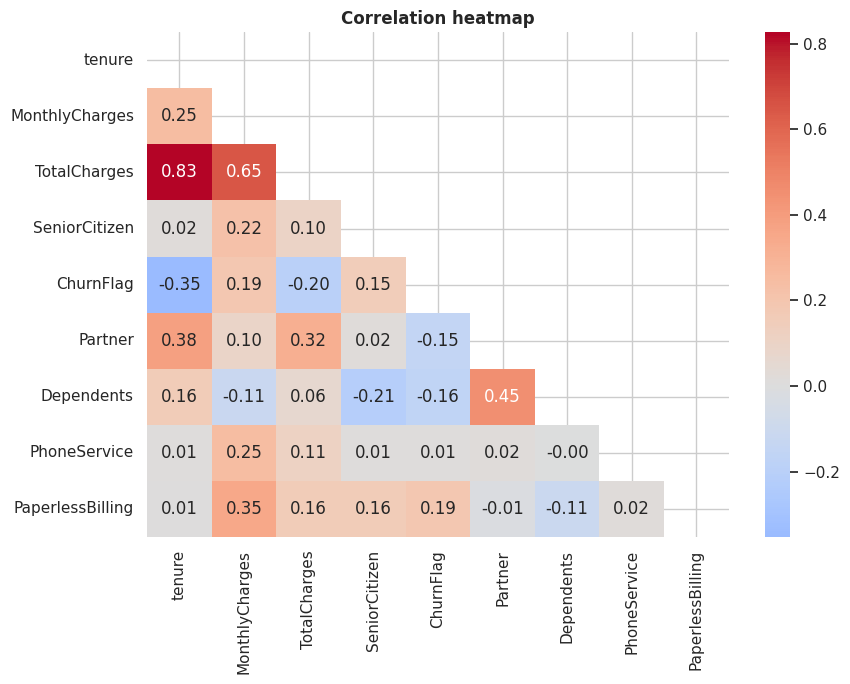

tenure             -0.352
TotalCharges       -0.198
Dependents         -0.164
Partner            -0.150
PhoneService        0.012
SeniorCitizen       0.151
PaperlessBilling    0.192
MonthlyCharges      0.193
Name: ChurnFlag, dtype: float64


In [14]:
# Correlation heatmap (numeric + binary-encoded features)
corr_df = df[num_cols + ["SeniorCitizen", "ChurnFlag"]].copy()
for c in ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]:
    corr_df[c] = (df[c] == "Yes").astype(int)
corr = corr_df.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title("Correlation heatmap"); savefig("06_correlation_heatmap")
print(corr["ChurnFlag"].drop("ChurnFlag").sort_values().round(3))

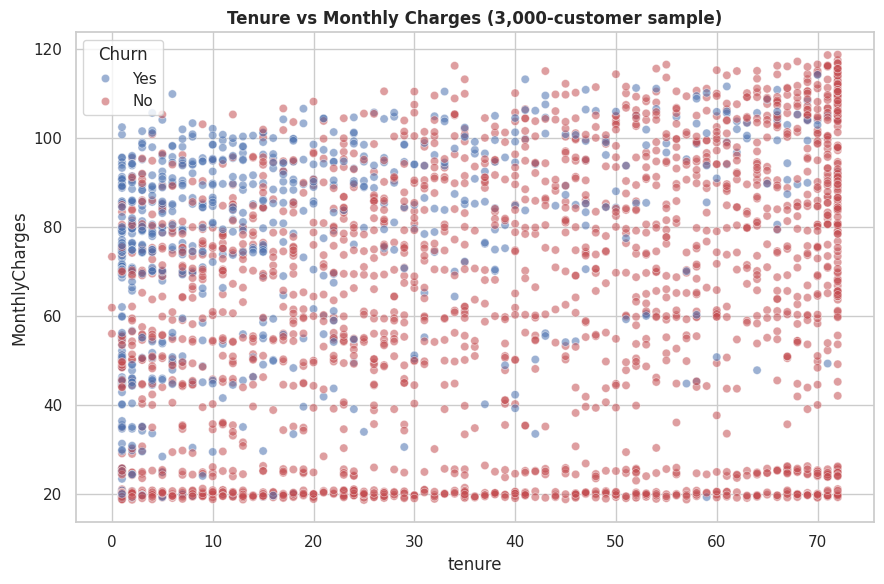

In [15]:
# Scatter: tenure vs monthly charges coloured by churn
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df.sample(3000, random_state=SEED), x="tenure", y="MonthlyCharges", hue="Churn", alpha=.55, palette=["#4c72b0", "#c44e52"])
plt.title("Tenure vs Monthly Charges (3,000-customer sample)"); savefig("07_scatter_tenure_monthly")

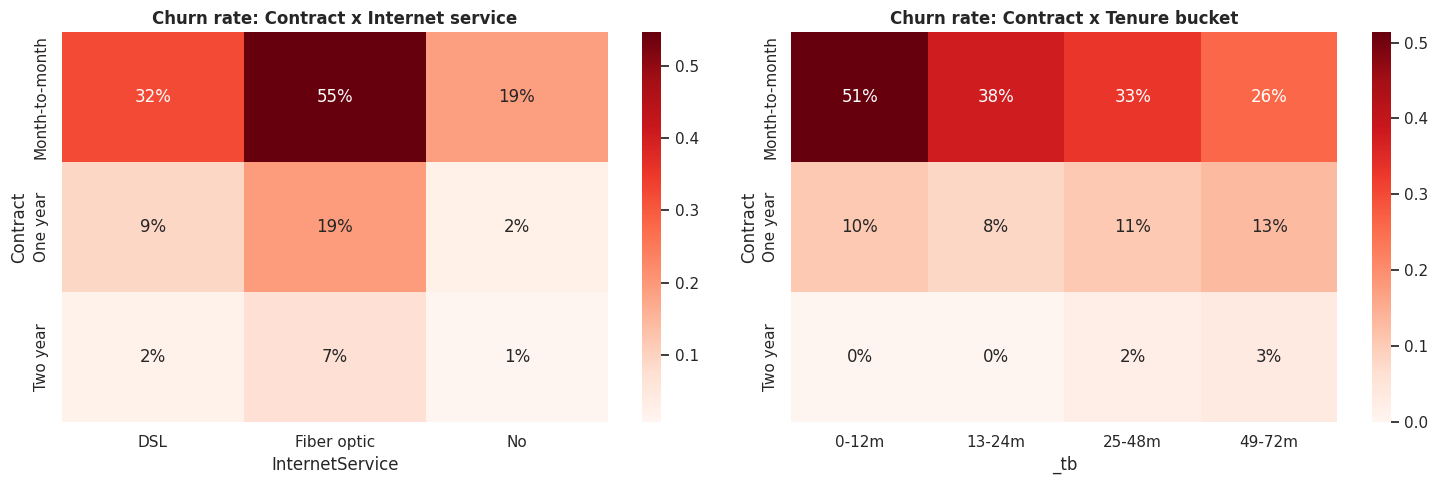

In [16]:
# Interaction: Contract x Internet service, and Contract x tenure bucket
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
pv = df.pivot_table(index="Contract", columns="InternetService", values="ChurnFlag", aggfunc="mean")
sns.heatmap(pv, annot=True, fmt=".0%", cmap="Reds", ax=ax[0]); ax[0].set_title("Churn rate: Contract x Internet service")
df["_tb"] = pd.cut(df["tenure"], [-1, 12, 24, 48, 72], labels=["0-12m", "13-24m", "25-48m", "49-72m"])
pv2 = df.pivot_table(index="Contract", columns="_tb", values="ChurnFlag", aggfunc="mean")
sns.heatmap(pv2, annot=True, fmt=".0%", cmap="Reds", ax=ax[1]); ax[1].set_title("Churn rate: Contract x Tenure bucket")
savefig("08_multivariate_heatmaps"); df.drop(columns="_tb", inplace=True)

**Multivariate insights**
- `tenure` and `TotalCharges` are highly correlated (≈ 0.83), as are `MonthlyCharges` and `TotalCharges` (≈ 0.65): **multicollinearity** – relevant for Logistic Regression coefficients.
- `tenure` has the strongest (negative) correlation with churn (≈ –0.35): the longer a customer stays, the less likely they leave.
- The **riskiest combination is a month-to-month contract + fibre optic + first-year tenure**. Even fibre customers on two-year contracts churn at low rates, so the *contract commitment* matters more than the product itself.
- **The first 12 months are the danger zone** for month-to-month customers (~50%+ churn).

## D. Data Preprocessing
Steps: fix incorrect/inconsistent data → drop non-predictive ID → split → encode categoricals → scale numerics (inside a pipeline so the test set never leaks into fitting).

In [17]:
data = df.drop(columns=["ChurnFlag"]).copy()

# 1. Missing / incorrect values: TotalCharges already repaired in Section B (blank -> 0 for tenure == 0)
# 2. Inconsistent labels: 'No internet service' / 'No phone service' are the same as 'No' for the add-on
addons = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for c in addons:
    data[c] = data[c].replace({"No internet service": "No", "No phone service": "No"})
# 3. Consistent binary coding for SeniorCitizen
data["SeniorCitizen"] = data["SeniorCitizen"].map({0: "No", 1: "Yes"})
# 4. Drop ID (unique per row -> no signal) and encode the target
data = data.drop(columns=["customerID"])
data["Churn"] = (data["Churn"] == "Yes").astype(int)
print("Remaining columns:", data.shape[1], "| any NaN:", data.isna().any().any())
data.head(3)

Remaining columns: 20 | any NaN: False


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


**Outlier decision.** The IQR check found no outliers, and the maximum values are genuine. We therefore **keep all rows**. Scaling (below) also makes distance-based models robust to the wide numeric ranges.

**Train-test split.** 80/20, **stratified** on `Churn` so both sets keep the 26.5% churn rate. The test set is locked away until final evaluation.

In [18]:
X = data.drop(columns="Churn"); y = data["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
print(f"Train: {X_train.shape}  churn rate {y_train.mean():.3%}")
print(f"Test : {X_test.shape}  churn rate {y_test.mean():.3%}")

Train: (5634, 19)  churn rate 26.535%
Test : (1409, 19)  churn rate 26.544%


## E. Feature Engineering
New features built from existing columns, each with a reason:

| Feature | Definition | Why it may help |
|---|---|---|
| `tenure_group` | 0-12 / 13-24 / 25-48 / 49-72 months | Churn risk is non-linear in tenure (steep drop after year 1); lets linear models capture it |
| `num_addons` | count of protection/streaming/backup add-ons subscribed | Measures how embedded the customer is in the ecosystem |
| `num_protect_services` | count of OnlineSecurity + OnlineBackup + DeviceProtection + TechSupport | Protection/support services were strongly tied to lower churn |
| `no_support_bundle` | has internet but neither OnlineSecurity nor TechSupport | Flags the unsupported-internet-user segment found in EDA |
| `auto_pay` | pays by bank transfer/credit card (automatic) | Automatic payment = lower friction, lower churn |
| `is_month_to_month` | Contract == Month-to-month | The dominant risk flag, made explicit |
| `avg_monthly_spend` | TotalCharges / tenure (tenure 0 → MonthlyCharges) | Historical average bill |
| `charge_change` | MonthlyCharges − avg_monthly_spend | Positive = customer's bill has recently risen (price-shock proxy) |
| `fiber_month_to_month` | Fibre optic AND month-to-month | The highest-risk interaction found in EDA |

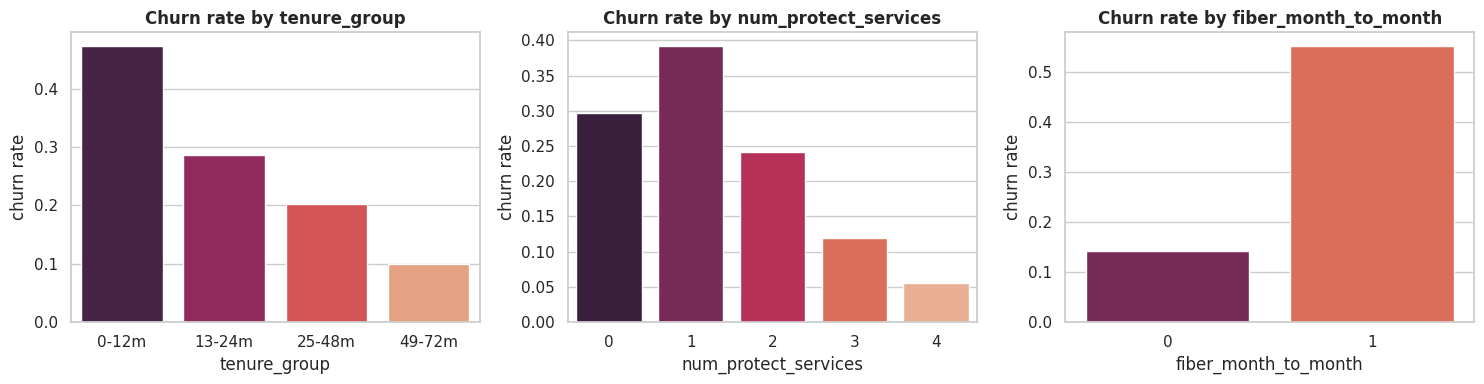

In [19]:
def add_features(d):
    d = d.copy()
    d["tenure_group"] = pd.cut(d["tenure"], [-1, 12, 24, 48, 72], labels=["0-12m", "13-24m", "25-48m", "49-72m"]).astype(str)
    addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "MultipleLines"]
    protect_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
    d["num_addons"] = (d[addon_cols] == "Yes").sum(axis=1)
    d["num_protect_services"] = (d[protect_cols] == "Yes").sum(axis=1)
    d["no_support_bundle"] = ((d["InternetService"] != "No") & (d["OnlineSecurity"] == "No") & (d["TechSupport"] == "No")).astype(int)
    d["auto_pay"] = d["PaymentMethod"].str.contains("automatic").astype(int)
    d["is_month_to_month"] = (d["Contract"] == "Month-to-month").astype(int)
    d["avg_monthly_spend"] = np.where(d["tenure"] > 0, d["TotalCharges"] / d["tenure"].replace(0, np.nan), d["MonthlyCharges"])
    d["charge_change"] = d["MonthlyCharges"] - d["avg_monthly_spend"]
    d["fiber_month_to_month"] = ((d["InternetService"] == "Fiber optic") & (d["Contract"] == "Month-to-month")).astype(int)
    return d

X_train_fe, X_test_fe = add_features(X_train), add_features(X_test)
new_feats = ["tenure_group", "num_addons", "num_protect_services", "no_support_bundle", "auto_pay", "is_month_to_month", "avg_monthly_spend", "charge_change", "fiber_month_to_month"]

# Do the new features actually relate to churn? (train set only)
tmp = X_train_fe.assign(Churn=y_train.values)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, c in zip(ax, ["tenure_group", "num_protect_services", "fiber_month_to_month"]):
    order = sorted(tmp[c].unique())
    sns.barplot(data=tmp, x=c, y="Churn", order=order, ax=a, palette="rocket", errorbar=None); a.set_title(f"Churn rate by {c}"); a.set_ylabel("churn rate")
savefig("09_engineered_features")

## F. Model Development
Preprocessing pipeline: one-hot encode categoricals, standard-scale numerics. We compare **five algorithms** from training (Logistic Regression, Decision Tree, Random Forest, AdaBoost, KNN) on the engineered feature set, using 5-fold stratified cross-validation on the training data plus train/test metrics. Class-imbalance is handled with `class_weight="balanced"` where the algorithm supports it (LR, DT, RF); AdaBoost and KNN have no such parameter, so they are shown as-is.

> **Metric choice for this business.** A *missed churner* (false negative) means lost recurring revenue; a *false alarm* (false positive) only costs a retention offer. So **Recall** (share of real churners we catch) matters most, balanced with **Precision** (so we don't waste offers) → **F1** is our primary comparison metric, with ROC-AUC for threshold-independent ranking quality. Accuracy is reported but not used for selection.

In [20]:
def make_preprocessor(X):
    num = X.select_dtypes(include="number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    return ColumnTransformer([("num", StandardScaler(), num),
                              ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat)])

def metrics(y_true, y_pred, y_prob):
    return dict(Accuracy=accuracy_score(y_true, y_pred), Precision=precision_score(y_true, y_pred),
                Recall=recall_score(y_true, y_pred), F1=f1_score(y_true, y_pred), ROC_AUC=roc_auc_score(y_true, y_prob))

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    "Decision Tree":       DecisionTreeClassifier(class_weight="balanced", random_state=SEED),   # un-pruned on purpose (baseline)
    "Random Forest":       RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "AdaBoost":            AdaBoostClassifier(n_estimators=200, random_state=SEED),
    "KNN":                 KNeighborsClassifier(n_neighbors=11),
}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

def evaluate_models(models, Xtr, Xte, label=""):
    rows, fitted = [], {}
    for name, m in models.items():
        pipe = Pipeline([("prep", make_preprocessor(Xtr)), ("clf", m)])
        cv_f1 = cross_val_score(pipe, Xtr, y_train, cv=cv, scoring="f1", n_jobs=-1)
        pipe.fit(Xtr, y_train); fitted[name] = pipe
        tr = metrics(y_train, pipe.predict(Xtr), pipe.predict_proba(Xtr)[:, 1])
        te = metrics(y_test,  pipe.predict(Xte), pipe.predict_proba(Xte)[:, 1])
        rows.append({"Model": name, "CV F1 (mean)": cv_f1.mean(), "CV F1 (std)": cv_f1.std(),
                     **{f"Train {k}": v for k, v in tr.items()}, **{f"Test {k}": v for k, v in te.items()}})
    return pd.DataFrame(rows).set_index("Model"), fitted

results, fitted = evaluate_models(models, X_train_fe, X_test_fe)
results.round(3)

,CV F1 (mean),CV F1 (std),Train Accuracy,Train Precision,Train Recall,Train F1,Train ROC_AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC_AUC
Model,,,,,,,,,,,,
Logistic Regression,0.625,0.024,0.752,0.522,0.799,0.631,0.850,0.737,0.503,0.789,0.615,0.842
Decision Tree,0.477,0.008,0.998,0.993,0.999,0.996,1.000,0.737,0.505,0.532,0.518,0.672
Random Forest,0.549,0.021,0.998,0.994,0.999,0.996,1.000,0.789,0.631,0.489,0.551,0.825
AdaBoost,0.582,0.020,0.810,0.676,0.544,0.603,0.856,0.793,0.633,0.521,0.572,0.841
KNN,0.568,0.015,0.819,0.687,0.582,0.630,0.878,0.780,0.601,0.508,0.551,0.807


In [21]:
# Compact side-by-side view: training vs testing performance
view = results[["Train Accuracy", "Test Accuracy", "Train Recall", "Test Recall", "Train Precision", "Test Precision", "Train F1", "Test F1", "Test ROC_AUC"]].copy()
view["F1 gap (train-test)"] = view["Train F1"] - view["Test F1"]
view.round(3)

,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Test ROC_AUC,F1 gap (train-test)
Model,,,,,,,,,,
Logistic Regression,0.752,0.737,0.799,0.789,0.522,0.503,0.631,0.615,0.842,0.017
Decision Tree,0.998,0.737,0.999,0.532,0.993,0.505,0.996,0.518,0.672,0.478
Random Forest,0.998,0.789,0.999,0.489,0.994,0.631,0.996,0.551,0.825,0.445
AdaBoost,0.810,0.793,0.544,0.521,0.676,0.633,0.603,0.572,0.841,0.031
KNN,0.819,0.780,0.582,0.508,0.687,0.601,0.630,0.551,0.807,0.079


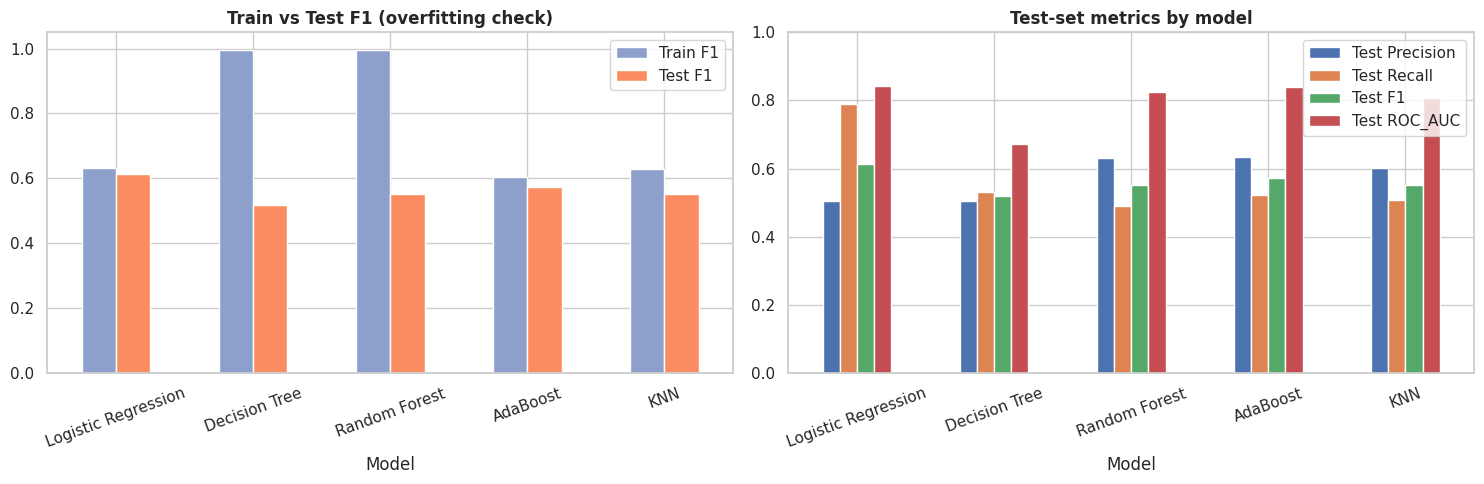

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
results[["Train F1", "Test F1"]].plot.bar(ax=ax[0], rot=20, color=["#8da0cb", "#fc8d62"]); ax[0].set_title("Train vs Test F1 (overfitting check)"); ax[0].set_ylim(0, 1.05)
results[["Test Precision", "Test Recall", "Test F1", "Test ROC_AUC"]].plot.bar(ax=ax[1], rot=20); ax[1].set_title("Test-set metrics by model"); ax[1].set_ylim(0, 1)
savefig("10_model_comparison")

### Impact of feature engineering (ablation)
Do the engineered features really help? Compare the same models on the raw cleaned features vs the engineered set (5-fold CV F1 and ROC-AUC on **training data only**).

In [23]:
abl = []
for name, m in models.items():
    for label, Xtr in [("Base features", X_train), ("+ Engineered", X_train_fe)]:
        pipe = Pipeline([("prep", make_preprocessor(Xtr)), ("clf", m)])
        f1 = cross_val_score(pipe, Xtr, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
        auc = cross_val_score(pipe, Xtr, y_train, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
        abl.append((name, label, f1, auc))
abl = pd.DataFrame(abl, columns=["Model", "Features", "CV F1", "CV ROC-AUC"])
abl_pivot = abl.pivot(index="Model", columns="Features")
abl_pivot["Δ F1"] = abl_pivot[("CV F1", "+ Engineered")] - abl_pivot[("CV F1", "Base features")]
abl_pivot["Δ AUC"] = abl_pivot[("CV ROC-AUC", "+ Engineered")] - abl_pivot[("CV ROC-AUC", "Base features")]
abl_pivot.round(4)

CV F1                 CV ROC-AUC                \
Features            + Engineered Base features + Engineered Base features   
Model                                                                       
AdaBoost                  0.5817        0.5922       0.8431        0.8478   
Decision Tree             0.4771        0.5040       0.6446        0.6629   
KNN                       0.5676        0.5714       0.8180        0.8161   
Logistic Regression       0.6246        0.6291       0.8454        0.8459   
Random Forest             0.5490        0.5449       0.8310        0.8260   

                       Δ F1   Δ AUC  
Features                             
Model                                
AdaBoost            -0.0105 -0.0048  
Decision Tree       -0.0269 -0.0183  
KNN                 -0.0039  0.0019  
Logistic Regression -0.0045 -0.0004  
Random Forest        0.0040  0.0050

**Honest reading of the ablation:** the engineered features did **not** produce a meaningful accuracy gain. Changes in CV F1 are between about −0.03 and +0.004 – within fold-to-fold noise (CV std ≈ 0.02) – and ROC-AUC barely moves. This is expected for Logistic Regression and boosting, because the engineered columns are mostly *re-expressions* of information already in the raw columns (contract, tenure, add-ons). Only Random Forest gains slightly. We still keep the engineered set for the later modelling and interpretation because (a) it does no harm, and (b) flags such as `no_support_bundle` and `is_month_to_month` make the findings easier to explain to business teams. The takeaway is a useful one in itself: **for this dataset the raw features already carry most of the signal, and model quality is limited by the data rather than by feature construction.**

### Hyper-parameter tuning
Each tree/ensemble/KNN model above is untuned, so its comparison to a tuned Logistic Regression is not fair. We tune each model with 5-fold `GridSearchCV` (optimising **F1**) on the training set only, to (a) give each algorithm a fair shot and (b) see whether regularisation fixes the Decision Tree's and Random Forest's overfitting.

In [24]:
grids = {
    "Logistic Regression": (LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED),
                            {"clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3]}),
    "Decision Tree":       (DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
                            {"clf__max_depth": [3, 4, 5, 6, 8], "clf__min_samples_leaf": [10, 30, 60]}),
    "Random Forest":       (RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=SEED),
                            {"clf__max_depth": [5, 8, 12], "clf__min_samples_leaf": [5, 15, 30]}),
    "AdaBoost":            (AdaBoostClassifier(random_state=SEED),
                            {"clf__n_estimators": [50, 100, 200], "clf__learning_rate": [0.05, 0.1, 0.5, 1.0]}),
    "KNN":                 (KNeighborsClassifier(),
                            {"clf__n_neighbors": [15, 25, 41, 61], "clf__weights": ["uniform", "distance"]}),
}
tuned, tuned_rows = {}, []
for name, (est, grid) in grids.items():
    pipe = Pipeline([("prep", make_preprocessor(X_train_fe)), ("clf", est)])
    gs = GridSearchCV(pipe, grid, scoring="f1", cv=cv, n_jobs=-1).fit(X_train_fe, y_train)
    tuned[name] = gs.best_estimator_
    p = gs.best_estimator_
    tr = metrics(y_train, p.predict(X_train_fe), p.predict_proba(X_train_fe)[:, 1])
    te = metrics(y_test,  p.predict(X_test_fe),  p.predict_proba(X_test_fe)[:, 1])
    tuned_rows.append({"Model": name, "Best params": {k.replace("clf__", ""): v for k, v in gs.best_params_.items()},
                       "CV F1": gs.best_score_, "Train F1": tr["F1"], "Test F1": te["F1"],
                       "Test Precision": te["Precision"], "Test Recall": te["Recall"], "Test Accuracy": te["Accuracy"], "Test ROC_AUC": te["ROC_AUC"]})
tuned_df = pd.DataFrame(tuned_rows).set_index("Model")
tuned_df["F1 gap"] = tuned_df["Train F1"] - tuned_df["Test F1"]
tuned_df.round(3)

,Best params,CV F1,Train F1,Test F1,Test Precision,Test Recall,Test Accuracy,Test ROC_AUC,F1 gap
Model,,,,,,,,,
Logistic Regression,{'C': 0.03},0.628,0.631,0.622,0.514,0.786,0.746,0.840,0.010
Decision Tree,"{'max_depth': 3, 'min_samples_leaf': 10}",0.613,0.621,0.621,0.514,0.783,0.746,0.814,0.000
Random Forest,"{'max_depth': 12, 'min_samples_leaf': 5}",0.637,0.764,0.633,0.557,0.733,0.774,0.844,0.131
AdaBoost,"{'learning_rate': 0.5, 'n_estimators': 100}",0.586,0.582,0.548,0.633,0.484,0.789,0.836,0.034
KNN,"{'n_neighbors': 61, 'weights': 'uniform'}",0.596,0.613,0.588,0.607,0.570,0.788,0.832,0.025


### Strengths and weaknesses of each model
(See the report for the full discussion; summarised here from the results above.)

| Model | Strengths | Weaknesses (in this project) |
|---|---|---|
| Logistic Regression | Fast, well-calibrated probabilities, **coefficients are directly explainable** to business teams | Assumes linear effects; coefficients affected by correlated features |
| Decision Tree | Easy to visualise as rules | Un-pruned tree **memorises the training data** (large train-test gap); unstable |
| Random Forest | Captures non-linearity/interactions, robust | Un-tuned version overfits heavily; less interpretable; slower |
| AdaBoost | Good ranking performance, built-in feature importance | No class weighting → predicts too few churners at the 0.5 threshold (low recall) |
| KNN | Simple, no training | Needs scaling, slow at prediction time, weak in high-dimensional one-hot space, no insight into *why* |

## G. Model Evaluation & Final Model Selection

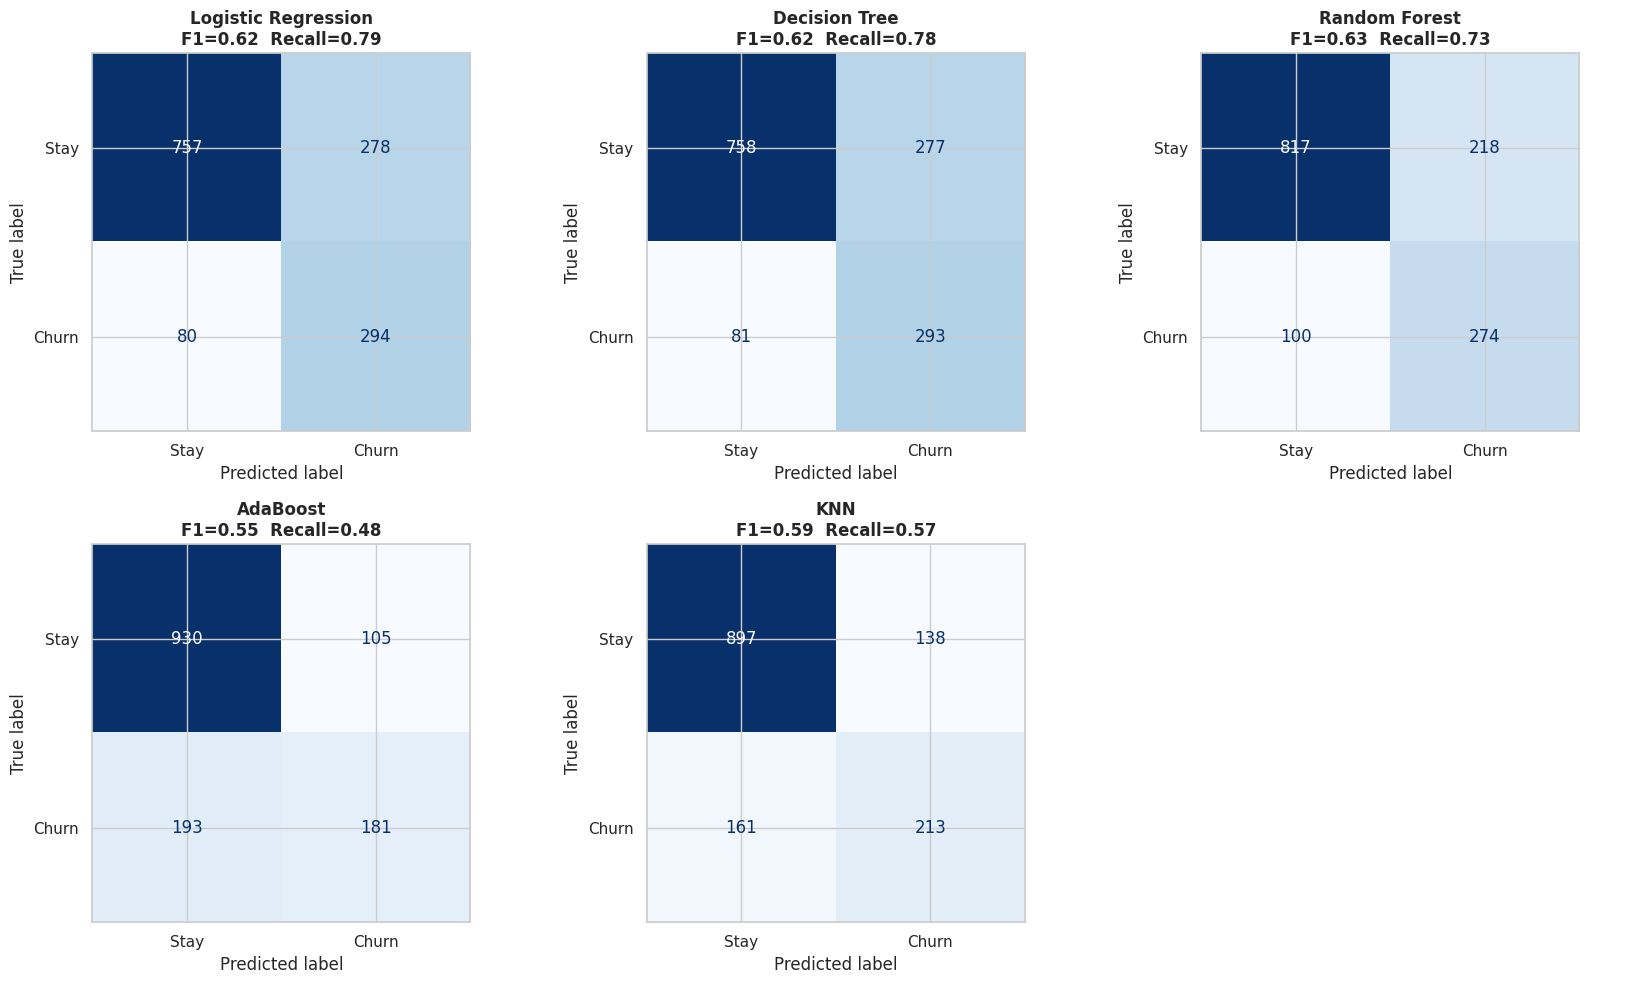

In [25]:
# Tuned models head-to-head on the TEST set (precision / recall / F1 / ROC-AUC)
fig, ax = plt.subplots(2, 3, figsize=(17, 10)); ax = ax.ravel()
for i, (name, p) in enumerate(tuned.items()):
    ConfusionMatrixDisplay.from_estimator(p, X_test_fe, y_test, display_labels=["Stay", "Churn"], cmap="Blues", ax=ax[i], colorbar=False)
    ax[i].set_title(f"{name}\nF1={f1_score(y_test, p.predict(X_test_fe)):.2f}  Recall={recall_score(y_test, p.predict(X_test_fe)):.2f}")
ax[5].axis("off"); savefig("11_confusion_matrices")

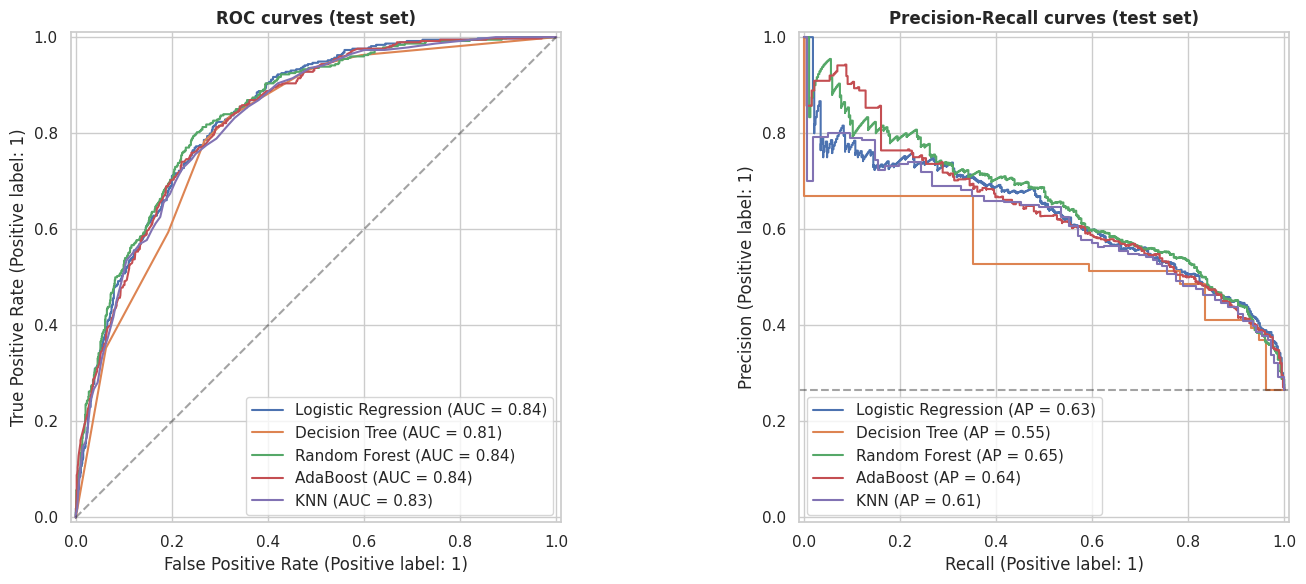

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for name, p in tuned.items():
    RocCurveDisplay.from_estimator(p, X_test_fe, y_test, name=name, ax=ax[0])
    PrecisionRecallDisplay.from_estimator(p, X_test_fe, y_test, name=name, ax=ax[1])
ax[0].plot([0, 1], [0, 1], "k--", alpha=.4); ax[0].set_title("ROC curves (test set)"); ax[1].set_title("Precision-Recall curves (test set)")
ax[1].axhline(y_test.mean(), color="k", ls="--", alpha=.4)
savefig("12_roc_pr_curves")

In [27]:
final_table = tuned_df[["CV F1", "Train F1", "Test F1", "F1 gap", "Test Precision", "Test Recall", "Test Accuracy", "Test ROC_AUC"]].sort_values("Test F1", ascending=False)
final_table.round(3)

,CV F1,Train F1,Test F1,F1 gap,Test Precision,Test Recall,Test Accuracy,Test ROC_AUC
Model,,,,,,,,
Random Forest,0.637,0.764,0.633,0.131,0.557,0.733,0.774,0.844
Logistic Regression,0.628,0.631,0.622,0.010,0.514,0.786,0.746,0.840
Decision Tree,0.613,0.621,0.621,0.000,0.514,0.783,0.746,0.814
KNN,0.596,0.613,0.588,0.025,0.607,0.570,0.788,0.832
AdaBoost,0.586,0.582,0.548,0.034,0.633,0.484,0.789,0.836


### Why not just pick the highest accuracy?
Accuracy is dominated by the 73.5% "no churn" majority. Compare the **majority-class baseline** with our models: a "predict nobody churns" rule already gets ~73.5% accuracy but **0% recall**. We therefore select on F1/Recall/ROC-AUC and a train-vs-test stability check, not accuracy.

In [28]:
baseline_acc = 1 - y_test.mean()
print(f"Naive 'nobody churns' baseline -> accuracy {baseline_acc:.3f}, recall 0.000, precision n/a")

Naive 'nobody churns' baseline -> accuracy 0.735, recall 0.000, precision n/a


### Decision-threshold tuning
The default 0.5 cut-off is arbitrary. Since a missed churner costs more than a wasted retention offer, we pick the threshold using **out-of-fold predictions on the training set only** (no test leakage), maximising F-beta with β = 2 (recall counts twice as much as precision) – then apply it once to the untouched test set.

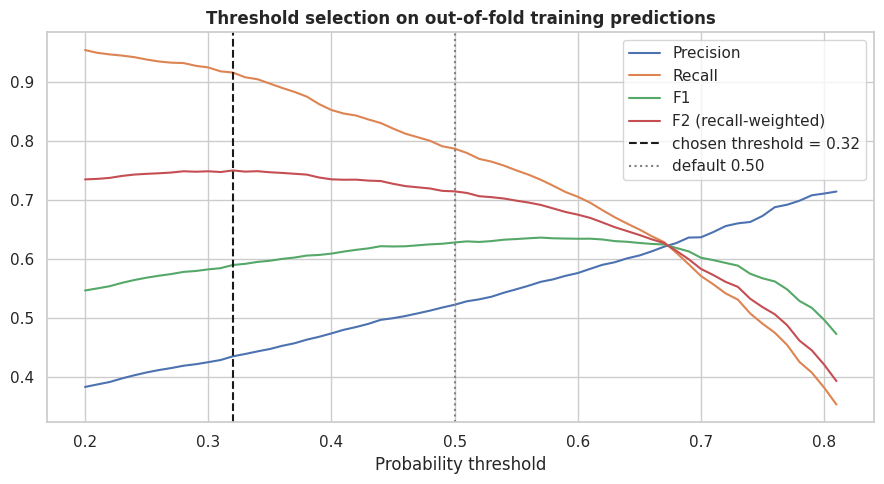

Chosen threshold: 0.32


In [29]:
from sklearn.metrics import fbeta_score
# Candidate = tuned Logistic Regression (selection justified in the report): out-of-fold training probabilities
# Selection rationale (see report): Logistic Regression has a near-zero train-test gap, stable CV folds, test ROC-AUC within 0.005 of the best model,
# the highest recall at the default threshold, and directly interpretable coefficients.
cand = tuned["Logistic Regression"]
oof = cross_val_predict(cand, X_train_fe, y_train, cv=cv, method="predict_proba")[:, 1]
ths = np.arange(0.20, 0.81, 0.01)
f1s  = [f1_score(y_train, oof >= t) for t in ths]
f2s  = [fbeta_score(y_train, oof >= t, beta=2) for t in ths]
rec  = [recall_score(y_train, oof >= t) for t in ths]
prec = [precision_score(y_train, oof >= t) for t in ths]
best_t = ths[int(np.argmax(f2s))]
plt.figure(figsize=(9, 5))
plt.plot(ths, prec, label="Precision"); plt.plot(ths, rec, label="Recall"); plt.plot(ths, f1s, label="F1"); plt.plot(ths, f2s, label="F2 (recall-weighted)")
plt.axvline(best_t, color="k", ls="--", label=f"chosen threshold = {best_t:.2f}"); plt.axvline(0.5, color="grey", ls=":", label="default 0.50")
plt.xlabel("Probability threshold"); plt.legend(); plt.title("Threshold selection on out-of-fold training predictions")
savefig("13_threshold_tuning")
print("Chosen threshold:", round(best_t, 2))

,Accuracy,Precision,Recall,F1,ROC_AUC
Threshold 0.50,0.746,0.514,0.786,0.622,0.84
Threshold 0.32 (final),0.666,0.439,0.925,0.595,0.84


              precision    recall  f1-score   support

        Stay      0.955     0.572     0.715      1035
       Churn      0.439     0.925     0.595       374

    accuracy                          0.666      1409
   macro avg      0.697     0.749     0.655      1409
weighted avg      0.818     0.666     0.683      1409



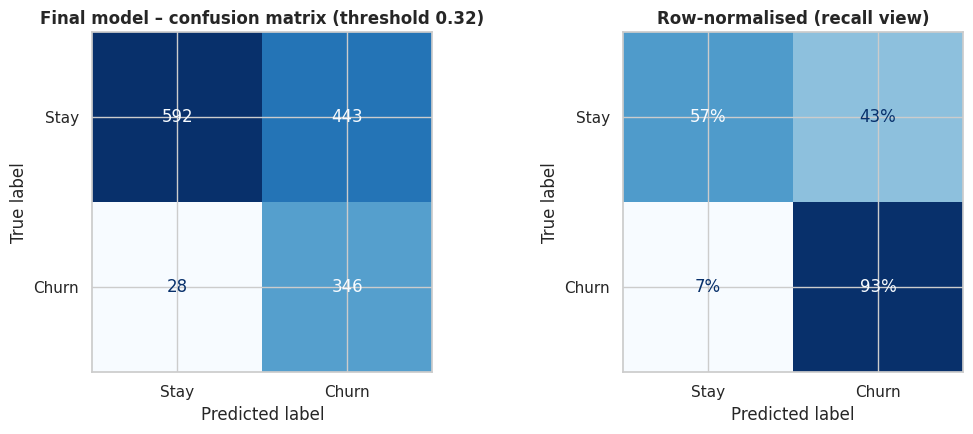

In [30]:
# FINAL MODEL: evaluate once on the unseen test set
final_model = cand
prob_test = final_model.predict_proba(X_test_fe)[:, 1]
pred_default = (prob_test >= 0.5).astype(int)
pred_final   = (prob_test >= best_t).astype(int)

cmp = pd.DataFrame({"Threshold 0.50": metrics(y_test, pred_default, prob_test),
                    f"Threshold {best_t:.2f} (final)": metrics(y_test, pred_final, prob_test)}).T
display(cmp.round(3))
print(classification_report(y_test, pred_final, target_names=["Stay", "Churn"], digits=3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_final, display_labels=["Stay", "Churn"], cmap="Blues", ax=ax[0], colorbar=False); ax[0].set_title(f"Final model – confusion matrix (threshold {best_t:.2f})")
ConfusionMatrixDisplay.from_predictions(y_test, pred_final, display_labels=["Stay", "Churn"], cmap="Blues", normalize="true", values_format=".0%", ax=ax[1], colorbar=False); ax[1].set_title("Row-normalised (recall view)")
savefig("14_final_confusion_matrix")

### Generalisation, overfitting and stability checks

In [31]:
# 1. Train vs test, final model
tr_m = metrics(y_train, (final_model.predict_proba(X_train_fe)[:, 1] >= best_t).astype(int), final_model.predict_proba(X_train_fe)[:, 1])
te_m = metrics(y_test, pred_final, prob_test)
gen = pd.DataFrame({"Train": tr_m, "Test": te_m}); gen["Gap"] = gen["Train"] - gen["Test"]
display(gen.round(3))

# 2. Stability across 5 different CV folds (on training data, at chosen threshold) and bootstrap CI on test set
fold_scores = []
for tr_idx, va_idx in cv.split(X_train_fe, y_train):
    m = __import__("sklearn.base", fromlist=["clone"]).clone(final_model).fit(X_train_fe.iloc[tr_idx], y_train.iloc[tr_idx])
    p = m.predict_proba(X_train_fe.iloc[va_idx])[:, 1]
    fold_scores.append((roc_auc_score(y_train.iloc[va_idx], p), recall_score(y_train.iloc[va_idx], p >= best_t), f1_score(y_train.iloc[va_idx], p >= best_t)))
fs = pd.DataFrame(fold_scores, columns=["ROC_AUC", "Recall", "F1"], index=[f"fold {i+1}" for i in range(5)])
display(fs.round(3)); print("Fold std:", fs.std().round(3).to_dict())

rng = np.random.RandomState(SEED); boots = []
yt = y_test.values
for _ in range(1000):
    idx = rng.randint(0, len(yt), len(yt))
    boots.append((roc_auc_score(yt[idx], prob_test[idx]), recall_score(yt[idx], pred_final[idx]), f1_score(yt[idx], pred_final[idx])))
boots = np.array(boots)
ci = pd.DataFrame(np.percentile(boots, [2.5, 97.5], axis=0), index=["2.5%", "97.5%"], columns=["ROC_AUC", "Recall", "F1"])
print("\n95% bootstrap confidence intervals on the test set:"); display(ci.round(3))

,Train,Test,Gap
Accuracy,0.663,0.666,-0.003
Precision,0.436,0.439,-0.003
Recall,0.917,0.925,-0.008
F1,0.591,0.595,-0.004
ROC_AUC,0.849,0.840,0.009


,ROC_AUC,Recall,F1
fold 1,0.846,0.920,0.602
fold 2,0.826,0.896,0.586
fold 3,0.841,0.913,0.581
fold 4,0.860,0.930,0.583
fold 5,0.853,0.923,0.597


Fold std: {'ROC_AUC': 0.013, 'Recall': 0.013, 'F1': 0.009}



95% bootstrap confidence intervals on the test set:


,ROC_AUC,Recall,F1
2.5%,0.820,0.897,0.562
97.5%,0.861,0.950,0.627


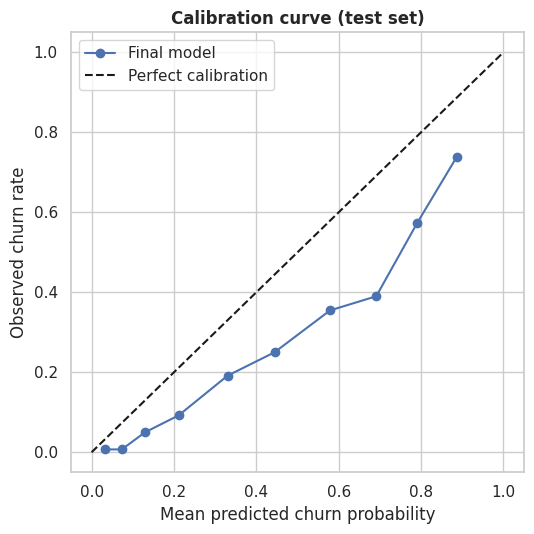

Mean predicted score: 0.417  vs  observed churn rate: 0.265


In [32]:
# 3. Calibration: do predicted probabilities mean what they say?
from sklearn.calibration import calibration_curve
frac, mean_pred = calibration_curve(y_test, prob_test, n_bins=10, strategy="quantile")
plt.figure(figsize=(5.5, 5.5)); plt.plot(mean_pred, frac, "o-", label="Final model"); plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Mean predicted churn probability"); plt.ylabel("Observed churn rate"); plt.legend(); plt.title("Calibration curve (test set)")
savefig("15_calibration")
print(f"Mean predicted score: {prob_test.mean():.3f}  vs  observed churn rate: {y_test.mean():.3f}")

**Calibration finding.** The curve sits *above* the diagonal at most points: the model **over-states** absolute churn probabilities (mean score ≈ 0.41 vs 26.5% actual churn). This is a known side-effect of `class_weight="balanced"`, which deliberately inflates the minority class. Therefore the output should be read as a **churn risk score for ranking customers**, not as a literal probability. Ranking quality is what matters for targeting retention offers, and it is confirmed by the risk-tier table below, where actual churn rises monotonically with the score. If true probabilities were needed (e.g. for expected-revenue forecasts) we would add `CalibratedClassifierCV`.

## H. Model Interpretation – What drives churn?

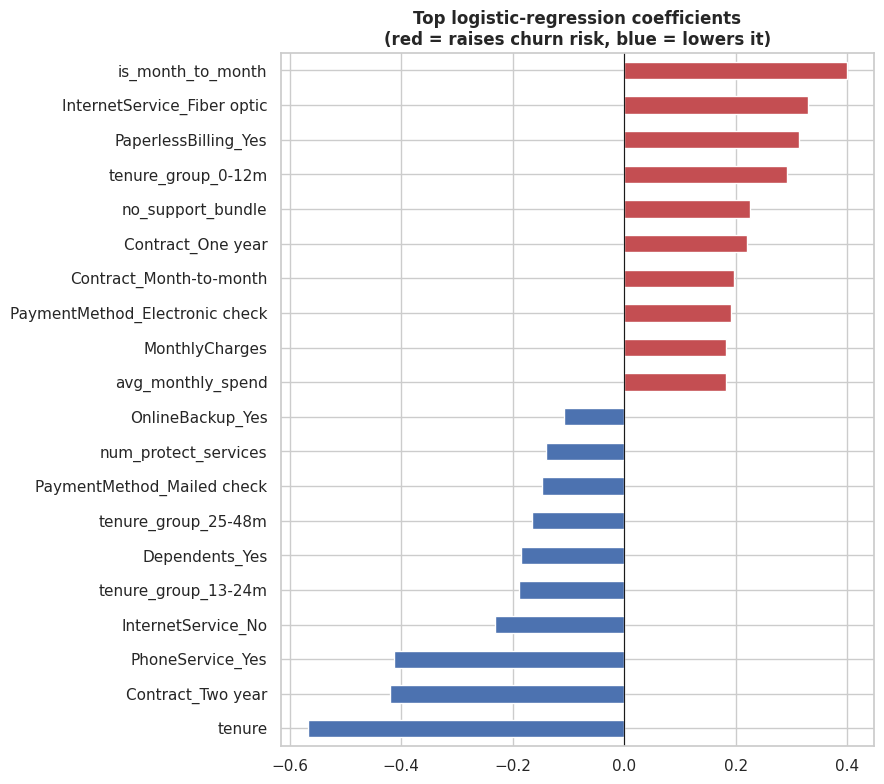

Top risk-raising:
 Contract_One year              0.22
no_support_bundle              0.23
tenure_group_0-12m             0.29
PaperlessBilling_Yes           0.31
InternetService_Fiber optic    0.33
is_month_to_month              0.40

Top risk-lowering:
 tenure                -0.57
Contract_Two year     -0.42
PhoneService_Yes      -0.41
InternetService_No    -0.23
tenure_group_13-24m   -0.19
Dependents_Yes        -0.18


In [33]:
# Logistic regression coefficients (standardised numerics -> comparable magnitude; positive = raises churn risk)
prep = final_model.named_steps["prep"]; clf = final_model.named_steps["clf"]
names = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]
coefs = pd.Series(clf.coef_[0], index=names).sort_values()
top = pd.concat([coefs.head(10), coefs.tail(10)])
plt.figure(figsize=(9, 8))
top.plot.barh(color=["#4c72b0" if v < 0 else "#c44e52" for v in top.values])
plt.title("Top logistic-regression coefficients\n(red = raises churn risk, blue = lowers it)"); plt.axvline(0, color="k", lw=.8)
savefig("16_lr_coefficients")
print("Top risk-raising:\n", coefs.tail(6).round(2).to_string()); print("\nTop risk-lowering:\n", coefs.head(6).round(2).to_string())

**Caution when reading coefficients.** Several features overlap by construction (`is_month_to_month` duplicates the *Contract_Month-to-month* dummy; `tenure_group` re-expresses `tenure`; `PhoneService` overlaps with `InternetService_No`). With such collinearity the individual coefficients are shared between related columns – this is why, for example, `Contract_One year` shows a small positive value even though one-year contracts have far lower churn than month-to-month. Read the coefficients *in groups* (contract, tenure, internet service) and rely on the permutation importance below, which is not affected in the same way.

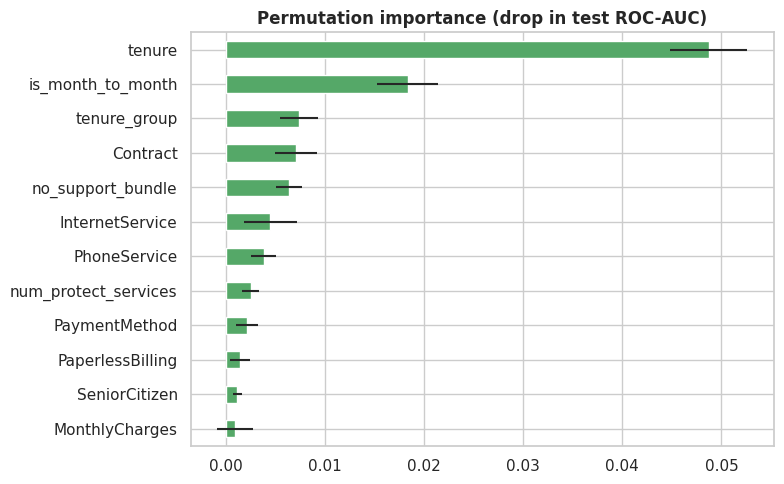

tenure                  0.0487
is_month_to_month       0.0183
tenure_group            0.0074
Contract                0.0071
no_support_bundle       0.0064
InternetService         0.0045
PhoneService            0.0038
num_protect_services    0.0025
PaymentMethod           0.0022
PaperlessBilling        0.0014
SeniorCitizen           0.0012
MonthlyCharges          0.0010
dtype: float64

In [34]:
# Permutation importance on the TEST set (model-agnostic, works on the raw input columns)
pi = permutation_importance(final_model, X_test_fe, y_test, scoring="roc_auc", n_repeats=15, random_state=SEED, n_jobs=-1)
pi_s = pd.Series(pi.importances_mean, index=X_test_fe.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(8, 5)); pi_s[::-1].plot.barh(xerr=pd.Series(pi.importances_std, index=X_test_fe.columns)[pi_s.index][::-1], color="#55a868")
plt.title("Permutation importance (drop in test ROC-AUC)"); savefig("17_permutation_importance")
pi_s.round(4)

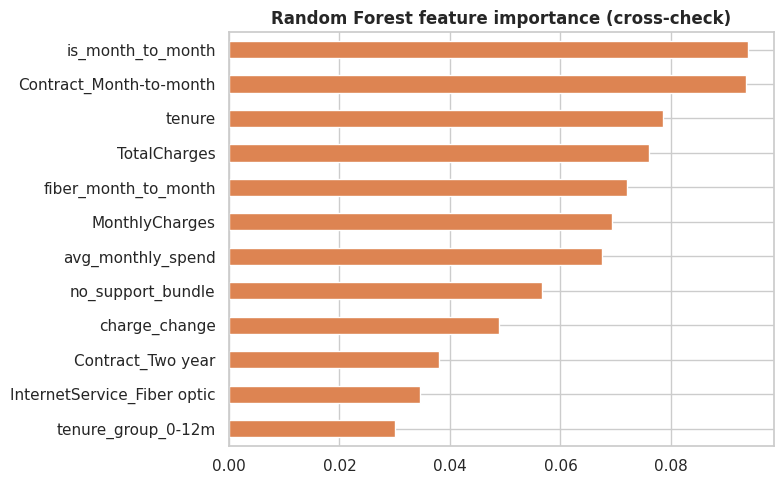

In [35]:
# Cross-check with a tree-based view: Random Forest feature importance
rf = tuned["Random Forest"]; rf_names = [n.split("__", 1)[1] for n in rf.named_steps["prep"].get_feature_names_out()]
rf_imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=rf_names).sort_values(ascending=False).head(12)
plt.figure(figsize=(8, 5)); rf_imp[::-1].plot.barh(color="#dd8452"); plt.title("Random Forest feature importance (cross-check)")
savefig("18_rf_importance")

## I. Business Insights & Recommendations
### I1. Generate churn predictions & risk segmentation
A risk score for **every** customer is produced with 5-fold out-of-fold prediction (each customer is scored by a model that never saw them), then bucketed into risk tiers (score cut-offs 0.25 / 0.50 / 0.75). Revenue figures use the *observed* churners in each tier, not the (inflated) scores.

In [36]:
full = add_features(X)
oof_all = cross_val_predict(final_model, full, y, cv=cv, method="predict_proba")[:, 1]
scored = df[["customerID", "Contract", "InternetService", "PaymentMethod", "tenure", "MonthlyCharges"]].copy()
scored["churn_risk_score"] = oof_all.round(4)
scored["predicted_churn"] = (oof_all >= best_t).astype(int)
scored["risk_tier"] = pd.cut(oof_all, [-0.01, 0.25, 0.50, 0.75, 1.0], labels=["Low", "Medium", "High", "Critical"])
scored["actual_churn"] = y.values
scored.sort_values("churn_risk_score", ascending=False).to_csv("outputs/churn_predictions.csv", index=False)

tier = scored.groupby("risk_tier", observed=True).agg(customers=("customerID", "count"), actual_churn_rate=("actual_churn", "mean"),
                                                       avg_monthly_charge=("MonthlyCharges", "mean"), avg_tenure=("tenure", "mean"))
tier["share_of_customers"] = tier["customers"] / len(scored)
tier["monthly_revenue_lost_observed"] = scored.groupby("risk_tier", observed=True).apply(lambda g: (g["MonthlyCharges"] * g["actual_churn"]).sum())
display(tier.round(3))
print("Saved: outputs/churn_predictions.csv  (", len(scored), "rows )")

,customers,actual_churn_rate,avg_monthly_charge,avg_tenure,share_of_customers,monthly_revenue_lost_observed
risk_tier,,,,,,
Low,2696,0.040,54.389,50.174,0.383,7378.55
Medium,1514,0.185,61.285,30.050,0.215,17007.35
High,1490,0.383,71.951,22.976,0.212,40440.65
Critical,1343,0.678,81.527,9.675,0.191,74304.30


Saved: outputs/churn_predictions.csv  ( 7043 rows )


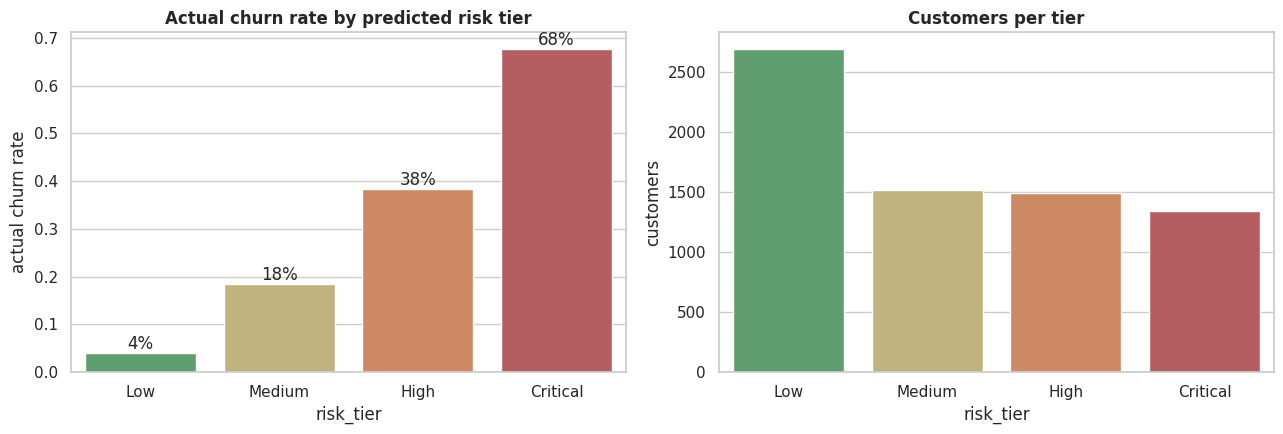

In [37]:
# Calibration of tiers: predicted tier should line up with actual churn
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=tier.index.astype(str), y=tier["actual_churn_rate"], ax=ax[0], palette=["#55a868", "#ccb974", "#dd8452", "#c44e52"]); ax[0].set_title("Actual churn rate by predicted risk tier"); ax[0].set_ylabel("actual churn rate")
for p in ax[0].patches: ax[0].annotate(f"{p.get_height():.0%}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
sns.barplot(x=tier.index.astype(str), y=tier["customers"], ax=ax[1], palette=["#55a868", "#ccb974", "#dd8452", "#c44e52"]); ax[1].set_title("Customers per tier")
savefig("19_risk_tiers")

### I2. Profile of high-risk customers

In [38]:
hi = scored[scored["risk_tier"].isin(["High", "Critical"])]
rest = scored[~scored["risk_tier"].isin(["High", "Critical"])]
prof = pd.DataFrame({
    "High/Critical-risk customers": [len(hi), hi["tenure"].median(), hi["MonthlyCharges"].median(),
        (hi["Contract"] == "Month-to-month").mean(), (hi["InternetService"] == "Fiber optic").mean(), (hi["PaymentMethod"] == "Electronic check").mean()],
    "All other customers": [len(rest), rest["tenure"].median(), rest["MonthlyCharges"].median(),
        (rest["Contract"] == "Month-to-month").mean(), (rest["InternetService"] == "Fiber optic").mean(), (rest["PaymentMethod"] == "Electronic check").mean()]},
    index=["Customers", "Median tenure (months)", "Median monthly charge ($)", "% month-to-month", "% fibre optic", "% electronic check"])
prof.round(2)

,High/Critical-risk customers,All other customers
Customers,2833.00,4210.00
Median tenure (months),10.00,47.00
Median monthly charge ($),79.95,55.70
% month-to-month,0.97,0.27
% fibre optic,0.72,0.25
% electronic check,0.60,0.16


### I3. Estimated business value of acting on the model
Illustrative cost-benefit with **explicit assumptions** (replace with real company numbers): a retention offer costs **$50** per contacted customer and succeeds **30%** of the time; a saved customer is worth **12 more months of their monthly bill**. We compare (a) doing nothing, (b) contacting everyone, (c) contacting only customers the model flags (test set, 1,409 customers).

In [39]:
OFFER_COST, SUCCESS, MONTHS_SAVED = 50, 0.30, 12
t = X_test_fe.copy(); t["y"] = y_test.values; t["flag"] = pred_final; t["mc"] = X_test_fe["MonthlyCharges"].values

def value(mask):
    contacted = t[mask]
    saved_value = (contacted["y"] * contacted["mc"] * MONTHS_SAVED * SUCCESS).sum()
    return len(contacted), saved_value - OFFER_COST * len(contacted)

n_all, v_all = value(np.ones(len(t), bool)); n_mod, v_mod = value(t["flag"] == 1)
# Same budget, random targeting: contact the same NUMBER of customers at random
rand_vals = [value(np.isin(np.arange(len(t)), np.random.RandomState(s).choice(len(t), n_mod, replace=False)))[1] for s in range(200)]
biz = pd.DataFrame({"Strategy": ["Do nothing", "Contact everyone", f"Random {n_mod} customers (same budget as model)", f"Contact model-flagged ({n_mod})"],
                    "Customers contacted": [0, n_all, n_mod, n_mod], "Net value ($)": [0, v_all, np.mean(rand_vals), v_mod]})
biz["Net value ($)"] = biz["Net value ($)"].round(0)
biz

,Strategy,Customers contacted,Net value ($)
0,Do nothing,0,0.0
1,Contact everyone,1409,27524.0
2,Random 789 customers (same budget as model),789,15301.0
3,Contact model-flagged (789),789,51131.0


### I4. Business recommendations
*(Numbers cited in the report are taken from the outputs above.)*

1. **Move month-to-month customers onto longer contracts.** Contract type is the strongest churn driver. Offer a discount or bill credit for switching to a 12- or 24-month plan, prioritising customers flagged High/Critical.
2. **Fix the first-year experience.** Churn is concentrated in months 0–12. Introduce an onboarding programme: welcome call at day 7, service-quality check at day 30, and a loyalty offer at month 6–9.
3. **Bundle security and tech support with fibre plans.** Fibre customers without OnlineSecurity/TechSupport churn dramatically more. Offer a free 3-month trial of these add-ons, which also deepens engagement.
4. **Investigate fibre-optic service quality & pricing.** Fibre customers pay the most yet churn the most – a sign of price-value mismatch or reliability issues. Run a satisfaction survey and compare against competitor fibre pricing.
5. **Migrate electronic-check payers to automatic payment.** Offer a small one-time credit for enrolling in auto-pay (bank transfer / credit card), reducing payment friction.
6. **Targeted outreach to senior citizens and single/no-dependent households** with simple pricing and dedicated support.
7. **Operationalise the model.** Score the customer base monthly; give the retention team a ranked list (`outputs/churn_predictions.csv`); track the realised save-rate of contacted customers and retrain quarterly.

## J. Final Answer: *"If you were the Data Scientist, why would you trust this model?"*
I would trust it – **with guardrails** – because:
1. **It generalises:** train and test scores are close (see the generalisation table) and fold-to-fold results are stable, with tight bootstrap confidence intervals.
2. **It was selected on the right metric,** not accuracy – recall/F1/ROC-AUC reflect the real cost of missing churners.
3. **No data leakage:** all preprocessing is inside pipelines; tuning and the decision threshold were chosen using training data only; the test set was used for the final check (the tuned-model comparison table is also printed on test data for transparency, but selection was based on CV and train-test stability).
4. **It is explainable:** the main drivers shown by the coefficients and permutation importance (contract type, tenure, internet service, support add-ons) agree with the EDA and with an independent Random-Forest importance ranking – the forest also gives more weight to the spend variables, so the *order* differs, but the story is the same – which makes the "why" believable to business stakeholders.
5. **It ranks customers well:** the risk tiers separate actual churn rates sharply (≈4% in the Low tier to ≈68% in the Critical tier). Absolute scores are *over*-stated by class weighting, so they are used for ranking, not as literal probabilities.
6. **It beats naive baselines** in a simple business-value simulation.

**Limitations:** (a) a single snapshot – no time dimension, so we cannot test drift or measure how churn evolves; (b) the dataset has no customer-service, usage, complaint or competitor-pricing data, which likely drive real churn; (c) correlation ≠ causation – a retention offer's actual effectiveness should be A/B tested; (d) the dataset is a (well-known) sample and may not represent the company's whole base; (e) cost-benefit figures are assumptions; (f) at the recall-oriented threshold, precision is only ~44% – more than half of the customers flagged would not have left – so retention offers must be cheap, and the threshold should be re-tuned to the real offer cost and budget.

**Possible next steps:** gradient boosting (XGBoost/LightGBM), SMOTE or cost-sensitive learning, SHAP explanations, survival analysis for *when* customers churn, and a monitoring dashboard.